# Tối ưu baseline HOG + SVM cho phân loại nhóm biển báo giao thông trên GTSDB

## 1. Giới thiệu bài toán và giả thuyết

Bài toán của nhóm là phân loại nhóm biển báo giao thông trên bộ dữ liệu GTSDB. Đầu vào chính là các ROI biển báo được crop từ ground-truth bounding box. Đầu ra là nhóm biển báo, ví dụ prohibitory, danger, mandatory và other.

Baseline chính của bài là HOG + SVM mặc định. HOG được dùng để mô tả cấu trúc cạnh, đường viền và hướng gradient cục bộ của biển báo. SVM dùng vector đặc trưng HOG để phân loại nhóm biển báo.

Giả thuyết chính:
Từ baseline HOG + SVM mặc định, việc tối ưu các tham số của HOG như ROI size, pixels_per_cell, orientations, cells_per_block có thể cải thiện Macro F1, vì các tham số này ảnh hưởng trực tiếp đến cách HOG biểu diễn chi tiết cạnh, viền và ký hiệu bên trong biển báo. Tiêu chí thành công là Macro F1 của Optimized HOG + SVM trên test set sạch cao hơn Macro F1 của Baseline HOG + SVM trong cùng split dữ liệu

Phạm vi bài:
Bài chỉ đánh giá classification trên ROI crop từ ground-truth bounding box. Bài không xử lý việc tìm bounding box trên ảnh gốc.

Tiêu chí đánh giá chính:

- **Accuracy**: đo tỷ lệ dự đoán đúng trên toàn bộ tập test.
- **Macro Precision**: đánh giá độ chính xác trung bình của từng nhóm lớp, không bị lớp nhiều mẫu chi phối quá mạnh.
- **Macro Recall**: đánh giá khả năng nhận diện trung bình của từng nhóm lớp.
- **Macro F1**: chỉ số chính được dùng để so sánh mô hình, vì cân bằng giữa Precision và Recall, đồng thời phù hợp khi số mẫu giữa các nhóm lớp không hoàn toàn cân bằng.
- **Feature dimension**: số chiều của vector đặc trưng HOG, dùng để đánh giá độ phức tạp của đặc trưng.
- **Trade-off giữa hiệu năng và độ phức tạp**: nhóm không chỉ chọn cấu hình có điểm số cao, mà còn xem xét số chiều đặc trưng. Một cấu hình tốt nên có Macro F1 cao nhưng vector đặc trưng không quá lớn.


## 2. Cơ sở nghiên cứu: HOG + SVM, GTSDB

HOG + SVM là một pipeline truyền thống trong nhận dạng/phát hiện đối tượng. HOG mô tả phân bố hướng gradient trong các cell cục bộ, sau đó các histogram được chuẩn hóa theo block để tạo vector đặc trưng. Vector này được đưa vào SVM để phân loại.

Với bài toán biển báo giao thông, HOG phù hợp vì biển báo có cấu trúc hình học rõ ràng như viền tròn, tam giác, chữ nhật, mũi tên, chữ số và biểu tượng bên trong.

Chất lượng HOG phụ thuộc vào:
- kích thước ROI;
- kích thước cell;
- số hướng gradient;
- số cell trong block;

Vì vậy, các thí nghiệm được chọn theo vai trò của từng tham số HOG.

## 3. Load dataset và phân bố dữ liệu

Yêu cầu GTSDB nằm trong `data/FullIJCNN2013/`. File `gt.txt` có dạng `filename;leftCol;topRow;rightCol;bottomRow;ClassID`. Các class chi tiết được gom thành bốn nhóm lớn để bài toán vừa đủ rõ ràng nhưng vẫn có ý nghĩa thực nghiệm.

Dữ liệu được chia theo ảnh gốc thay vì chia ngẫu nhiên từng crop. Cách này tránh trường hợp các crop từ cùng một ảnh xuất hiện đồng thời ở train và test, làm kết quả đánh giá bị sai.


In [103]:
from pathlib import Path
import random
import warnings

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.feature import hog
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix, ConfusionMatrixDisplay

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = lambda x, **kwargs: x

RANDOM_STATE = 126
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
warnings.filterwarnings("default")

DATA_ROOT = Path("data/FullIJCNN2013")
GT_PATH = DATA_ROOT / "gt.txt"

DATASET_HELP = """Bạn cần tải và giải nén GTSDB vào data/FullIJCNN2013/
Thư mục này phải có gt.txt và các ảnh 00000.ppm đến 00899.ppm."""

ppm_files = sorted(DATA_ROOT.glob("*.ppm")) if DATA_ROOT.exists() else []
if (not DATA_ROOT.exists()) or (not GT_PATH.exists()) or (len(ppm_files) == 0):
    print(DATASET_HELP)
    raise FileNotFoundError(DATASET_HELP)

print(f"Dataset root: {DATA_ROOT.resolve()}")
print(f"Số ảnh .ppm tìm thấy: {len(ppm_files)}")


Dataset root: C:\Users\ad\Downloads\codepython\Bai_Tap_ML\BTL_XLA\data\FullIJCNN2013
Số ảnh .ppm tìm thấy: 900


,filename,xmin,ymin,xmax,ymax,class_id,label_group
0,00000.ppm,774,411,815,446,11,danger
1,00001.ppm,983,388,1024,432,40,mandatory
2,00001.ppm,386,494,442,552,38,mandatory
3,00001.ppm,973,335,1031,390,13,other
4,00002.ppm,892,476,1006,592,39,mandatory


,số ảnh .ppm,số ảnh có annotation,số annotation,số biển báo
0,900,741,1213,1213


,count
label_group,
prohibitory,557
danger,219
mandatory,163
other,274


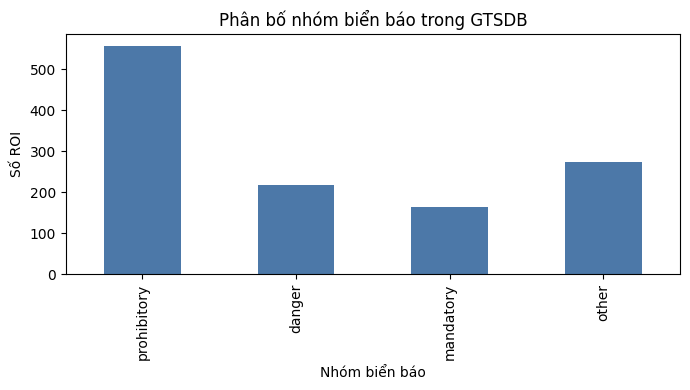

In [104]:
PROHIBITORY = [0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 15, 16]
DANGER = [11, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
MANDATORY = [33, 34, 35, 36, 37, 38, 39, 40]
OTHER = [6, 12, 13, 14, 17, 32, 41, 42]
GROUP_ORDER = ["prohibitory", "danger", "mandatory", "other"]


def map_class_group(class_id):
    class_id = int(class_id)
    if class_id in PROHIBITORY:
        return "prohibitory"
    if class_id in DANGER:
        return "danger"
    if class_id in MANDATORY:
        return "mandatory"
    if class_id in OTHER:
        return "other"
    return "unknown"


def load_gtsdb_annotations(gt_path):
    columns = ["filename", "xmin", "ymin", "xmax", "ymax", "class_id"]
    df = pd.read_csv(gt_path, sep=";", names=columns)
    df[["xmin", "ymin", "xmax", "ymax", "class_id"]] = df[["xmin", "ymin", "xmax", "ymax", "class_id"]].astype(int)
    df["label_group"] = df["class_id"].apply(map_class_group)
    unknown = sorted(df.loc[df["label_group"] == "unknown", "class_id"].unique())
    if unknown:
        raise ValueError(f"Có ClassID chưa được map nhóm: {unknown}")
    return df


df = load_gtsdb_annotations(GT_PATH)
display(df.head())

summary = pd.DataFrame([{
    "số ảnh .ppm": len(ppm_files),
    "số ảnh có annotation": df["filename"].nunique(),
    "số annotation": len(df),
    "số biển báo": len(df),
}])
display(summary)

class_distribution = df["label_group"].value_counts().reindex(GROUP_ORDER, fill_value=0).to_frame("count")
display(class_distribution)

ax = class_distribution.plot(kind="bar", figsize=(7, 4), color="#4C78A8", legend=False)
ax.set_title("Phân bố nhóm biển báo trong GTSDB")
ax.set_xlabel("Nhóm biển báo")
ax.set_ylabel("Số ROI")
plt.tight_layout()
plt.show()


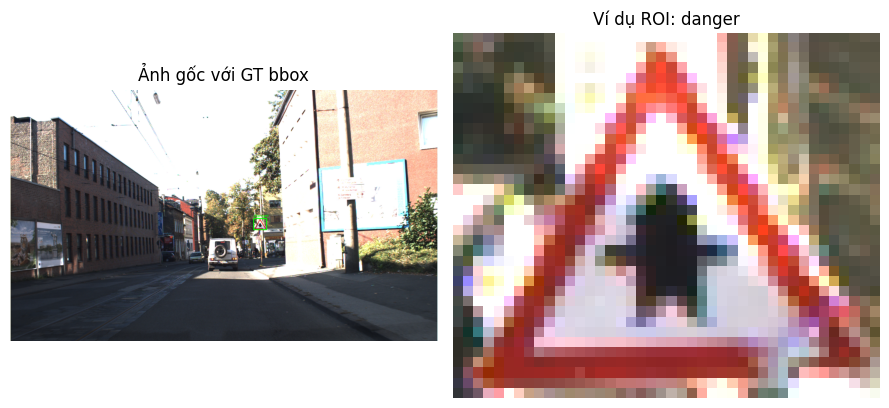

In [105]:
def read_image(path):
    image_bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise FileNotFoundError(f"Không đọc được ảnh: {path}")
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def clip_box(box, width, height):
    xmin, ymin, xmax, ymax = [int(round(v)) for v in box]
    xmin = max(0, min(xmin, width - 1))
    ymin = max(0, min(ymin, height - 1))
    xmax = max(0, min(xmax, width - 1))
    ymax = max(0, min(ymax, height - 1))
    if xmax < xmin:
        xmin, xmax = xmax, xmin
    if ymax < ymin:
        ymin, ymax = ymax, ymin
    return xmin, ymin, xmax, ymax


def crop_box(image, box):
    h, w = image.shape[:2]
    xmin, ymin, xmax, ymax = clip_box(box, w, h)
    return image[ymin:ymax + 1, xmin:xmax + 1]


def draw_boxes(image, boxes, labels=None, color=(0, 255, 0), thickness=2):
    out = image.copy()
    labels = labels if labels is not None else [None] * len(boxes)
    for box, label in zip(boxes, labels):
        x1, y1, x2, y2 = [int(v) for v in box]
        cv2.rectangle(out, (x1, y1), (x2, y2), color, thickness)
        if label:
            cv2.putText(out, str(label), (x1, max(0, y1 - 5)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1, cv2.LINE_AA)
    return out


sample_file = df["filename"].drop_duplicates().iloc[0]
sample_image = read_image(DATA_ROOT / sample_file)
sample_rows = df[df["filename"] == sample_file]
sample_boxes = sample_rows[["xmin", "ymin", "xmax", "ymax"]].values.tolist()
sample_labels = sample_rows["label_group"].tolist()

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(draw_boxes(sample_image, sample_boxes, sample_labels))
axes[0].set_title("Ảnh gốc với GT bbox")
axes[0].axis("off")
sample_crop = crop_box(sample_image, sample_boxes[0])
axes[1].imshow(sample_crop)
axes[1].set_title(f"Ví dụ ROI: {sample_labels[0]}")
axes[1].axis("off")
plt.tight_layout()
plt.show()


In [106]:
def make_filename_split(df, test_size=0.25, random_state=RANDOM_STATE):
    file_df = df[["filename"]].drop_duplicates().reset_index(drop=True)
    filenames = file_df["filename"].to_numpy()
    file_labels = df.groupby("filename")["label_group"].agg(lambda s: s.value_counts().idxmax()).reindex(filenames).to_numpy()
    splitter = GroupShuffleSplit(n_splits=50, test_size=test_size, random_state=random_state)
    all_labels = set(df["label_group"].unique())
    for train_file_idx, test_file_idx in splitter.split(filenames, file_labels, groups=filenames):
        train_files = set(filenames[train_file_idx])
        test_files = set(filenames[test_file_idx])
        train_labels = set(df[df["filename"].isin(train_files)]["label_group"].unique())
        test_labels = set(df[df["filename"].isin(test_files)]["label_group"].unique())
        if train_labels == all_labels and test_labels == all_labels:
            return train_files, test_files
    raise ValueError("Không tạo được filename split có đủ lớp trong train/test.")


train_files, test_files = make_filename_split(df)
print(f"Số file train: {len(train_files)}")
print(f"Số file test: {len(test_files)}")

split_distribution = pd.DataFrame({
    "train": df[df["filename"].isin(train_files)]["label_group"].value_counts().reindex(GROUP_ORDER, fill_value=0),
    "test": df[df["filename"].isin(test_files)]["label_group"].value_counts().reindex(GROUP_ORDER, fill_value=0),
})
display(split_distribution)


Số file train: 555
Số file test: 186


,train,test
label_group,,
prohibitory,396,161
danger,176,43
mandatory,123,40
other,222,52


Trong phần chính, nhóm sử dụng cách chia train/test để giữ pipeline đơn giản, dễ theo dõi và phù hợp với mục tiêu khảo sát HOG + SVM. Sau khi crop ROI từ GTSDB, số mẫu dùng cho bài toán phân loại 4 nhóm biển báo không quá lớn và phân bố giữa các nhóm lớp chưa hoàn toàn cân bằng. Nếu chia ngay thành train/validation/test ở phần chính, số mẫu trong từng split sẽ ít hơn, đặc biệt ở các nhóm có ít ROI, làm kết quả khảo sát tham số dễ dao động hơn.

Bên cạnh đó, nhóm giữ phạm vi dữ liệu ở mức vừa đủ để tập trung vào các bước chính của bài toán: đọc annotation, crop ROI, tiền xử lý ảnh, trích xuất đặc trưng HOG, huấn luyện SVM, trực quan hóa ảnh trung gian và chuẩn bị demo có thể chạy ổn định. Vì vậy, phần chính được xem như một bước khảo sát thực nghiệm để quan sát ảnh hưởng của các lựa chọn tiền xử lý và tham số HOG, thay vì một quy trình hyperparameter tuning hoàn toàn chặt chẽ.

Sau khi chọn được cấu hình HOG phù hợp, nhóm bổ sung Phụ lục A để kiểm tra lại theo protocol rõ ràng hơn. Trong phụ lục, dữ liệu được chia thành train/validation/test theo filename; validation được dùng để quan sát kết quả và chọn số chiều PCA, còn test chỉ dùng ở bước đánh giá cuối. Cách này giúp phần chính vẫn dễ trình bày và trực quan, đồng thời phần phụ lục bổ sung thêm kiểm chứng chặt chẽ hơn cho cấu hình đã chọn.

## 4. Feature extraction: HOG + gray_clahe
Các hàm dưới đây chỉ phục vụ bài toán classification trên ROI crop từ ground-truth bounding box. Preprocessing được cố định là `gray_clahe`; nhóm chỉ tối ưu các tham số HOG.

Lý do chốt `gray_clahe` là HOG mô tả cạnh và gradient, nên đầu vào phù hợp nhất là ảnh xám hoặc kênh cường độ sáng. 

Các lựa chọn khác như `gray` và `gray_clahe_blur` cũng được khảo sát phụ ở mục 4.1. Mục tiêu của khảo sát này là quan sát ảnh hưởng của tiền xử lý lên HOG, không dùng để thay đổi lại toàn bộ pipeline chính. Trong phần chính, nhóm giữ `gray_clahe` để tập trung khảo sát các tham số HOG.


In [107]:
DEFAULT_HOG_CONFIG = {
    "image_size": (64, 64),
    "orientations": 9,
    "pixels_per_cell": (8, 8),
    "cells_per_block": (2, 2),
    "block_norm": "L2-Hys",
    "preprocessing": "gray_clahe",
}


def normalize_tuple(value):
    if isinstance(value, tuple):
        return value
    if isinstance(value, list):
        return tuple(value)
    if isinstance(value, str):
        cleaned = value.strip().strip("()")
        parts = [p.strip() for p in cleaned.split(",") if p.strip()]
        return tuple(int(p) for p in parts)
    return value


def make_hog_config(**updates):
    config = DEFAULT_HOG_CONFIG.copy()
    config.update(updates)
    config["image_size"] = normalize_tuple(config["image_size"])
    config["pixels_per_cell"] = normalize_tuple(config["pixels_per_cell"])
    config["cells_per_block"] = normalize_tuple(config["cells_per_block"])
    return config


def config_key(config):
    return (
        normalize_tuple(config["image_size"]),
        int(config["orientations"]),
        normalize_tuple(config["pixels_per_cell"]),
        normalize_tuple(config["cells_per_block"]),
        config["block_norm"],
        config["preprocessing"],
    )


def preprocess_for_hog(image_rgb, image_size=(64, 64), preprocessing="gray_clahe"):
    resized = cv2.resize(image_rgb, image_size, interpolation=cv2.INTER_AREA)
    if preprocessing != "gray_clahe":
        raise ValueError(f"Chỉ hỗ trợ preprocessing cố định: gray_clahe, nhận được: {preprocessing}")
    gray = cv2.cvtColor(resized, cv2.COLOR_RGB2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(gray)


def extract_hog_feature(image_rgb, config):
    hog_input = preprocess_for_hog(
        image_rgb,
        image_size=normalize_tuple(config["image_size"]),
        preprocessing=config["preprocessing"],
    )
    return hog(
        hog_input,
        orientations=int(config["orientations"]),
        pixels_per_cell=normalize_tuple(config["pixels_per_cell"]),
        cells_per_block=normalize_tuple(config["cells_per_block"]),
        block_norm=config["block_norm"],
        visualize=False,
        feature_vector=True,
    ).astype(np.float32)


def extract_feature_from_crop(crop_rgb, config):
    return extract_hog_feature(crop_rgb, config)


In [108]:
def make_linear_svc(C=1.0):
    try:
        return LinearSVC(C=C, random_state=RANDOM_STATE, max_iter=30000, dual="auto")
    except TypeError:
        return LinearSVC(C=C, random_state=RANDOM_STATE, max_iter=30000)


FEATURE_CACHE = {}


def build_feature_dataset(df_all, image_dir, config):
    key = config_key(config)
    if key in FEATURE_CACHE:
        return FEATURE_CACHE[key]
    X, y, filenames = [], [], []
    for _, row in tqdm(df_all.iterrows(), total=len(df_all), desc="Extract ROI features"):
        image = read_image(image_dir / row["filename"])
        crop = crop_box(image, (row["xmin"], row["ymin"], row["xmax"], row["ymax"]))
        if crop.size == 0:
            continue
        feat = extract_feature_from_crop(crop, config)
        X.append(feat)
        y.append(row["label_group"])
        filenames.append(row["filename"])
    result = (np.vstack(X), np.array(y), np.array(filenames))
    FEATURE_CACHE[key] = result
    return result


def evaluate_hog_svm_config(model, role, config, C=1.0):
    X, y, filenames = build_feature_dataset(df, DATA_ROOT, config)
    train_mask = np.isin(filenames, list(train_files))
    test_mask = np.isin(filenames, list(test_files))
    clf = Pipeline([("scaler", StandardScaler()), ("model", make_linear_svc(C=C))])
    clf.fit(X[train_mask], y[train_mask])
    y_pred = clf.predict(X[test_mask])
    precision, recall, f1, _ = precision_recall_fscore_support(y[test_mask], y_pred, average="macro", zero_division=0)
    return {
        "model": model,
        "role": role,
        "image_size": normalize_tuple(config["image_size"]),
        "orientations": int(config["orientations"]),
        "pixels_per_cell": normalize_tuple(config["pixels_per_cell"]),
        "cells_per_block": normalize_tuple(config["cells_per_block"]),
        "block_norm": config["block_norm"],
        "preprocessing": config["preprocessing"],
        "accuracy": accuracy_score(y[test_mask], y_pred),
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1,
        "feature_dim": X.shape[1],
        "classifier": clf,
        "y_test": y[test_mask],
        "y_pred": y_pred,
    }


def result_table(results):
    cols = [
        "model", "role", "image_size", "orientations", "pixels_per_cell", "cells_per_block",
        "block_norm", "preprocessing", "accuracy", "macro_precision", "macro_recall", "macro_f1", "feature_dim",
    ]
    return pd.DataFrame([{k: r[k] for k in cols} for r in results])


def plot_macro_f1(df_result, x_col, title):
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(df_result[x_col].astype(str), df_result["macro_f1"], color="#59A14F")
    ax.set_title(title)
    ax.set_xlabel(x_col)
    ax.set_ylabel("Macro F1")
    ax.tick_params(axis="x", rotation=20)
    for idx, value in enumerate(df_result["macro_f1"]):
        ax.text(idx, value, f"{value:.3f}", ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()


### 4.1 Khảo sát phụ tiền xử lý: gray, gray_clahe, gray_clahe_blur

Phần này chạy thử 3 biến thể tiền xử lý để đáp ứng yêu cầu khảo sát tham số/biến thể của một kỹ thuật chính. Đây là thí nghiệm phụ để giải thích đầu vào cho HOG.

Ba biến thể được trình bày song song trên cùng một ROI:

- `gray`: chuyển ROI sang ảnh xám, giữ gradient gốc nhưng có thể thiếu tương phản cục bộ.
- `gray_clahe`: ảnh xám + CLAHE, tăng tương phản cục bộ để viền, mũi tên, chữ số và ký hiệu rõ hơn trước khi tính HOG.
- `gray_clahe_blur`: CLAHE rồi blur nhẹ, có thể giảm nhiễu nhưng cũng có nguy cơ làm mờ cạnh nhỏ mà HOG cần.

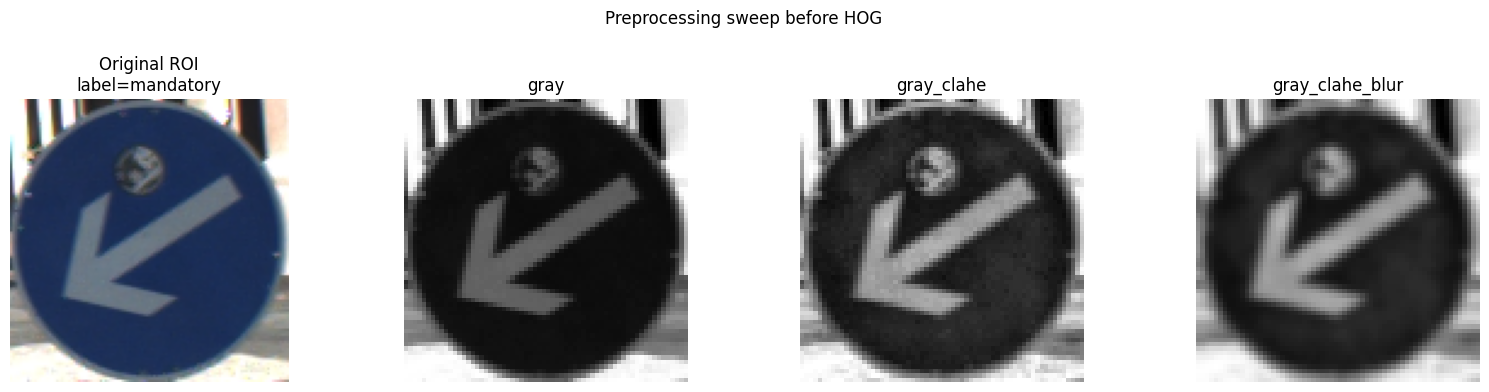

Preprocess sweep: gray_clahe_blur: 100%|██████████| 1213/1213 [00:06<00:00, 189.82it/s]


,preprocessing,accuracy,macro_precision,macro_recall,macro_f1,feature_dim
0,gray,0.986486,0.982431,0.977885,0.980117,1764
1,gray_clahe,0.976351,0.969670,0.965274,0.967432,1764
2,gray_clahe_blur,0.986486,0.979701,0.981140,0.980294,1764


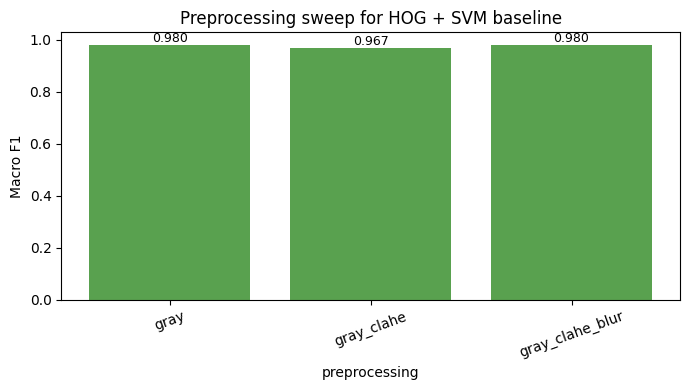

In [109]:
PREPROCESSING_SWEEP_MODES = ["gray", "gray_clahe", "gray_clahe_blur"]


def preprocess_for_sweep(image_rgb, image_size=(64, 64), mode="gray_clahe"):
    resized = cv2.resize(image_rgb, image_size, interpolation=cv2.INTER_AREA)
    gray = cv2.cvtColor(resized, cv2.COLOR_RGB2GRAY)
    if mode == "gray":
        return gray
    if mode == "gray_clahe":
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        return clahe.apply(gray)
    if mode == "gray_clahe_blur":
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        enhanced = clahe.apply(gray)
        return cv2.GaussianBlur(enhanced, (3, 3), 0)
    raise ValueError(f"Unsupported preprocessing mode: {mode}")


def extract_hog_feature_for_preprocessing_sweep(image_rgb, config, preprocessing_mode):
    hog_input = preprocess_for_sweep(
        image_rgb,
        image_size=normalize_tuple(config["image_size"]),
        mode=preprocessing_mode,
    )
    return hog(
        hog_input,
        orientations=int(config["orientations"]),
        pixels_per_cell=normalize_tuple(config["pixels_per_cell"]),
        cells_per_block=normalize_tuple(config["cells_per_block"]),
        block_norm=config["block_norm"],
        visualize=False,
        feature_vector=True,
    ).astype(np.float32)


PREPROCESSING_SWEEP_CACHE = {}


def build_feature_dataset_for_preprocessing_sweep(df_all, image_dir, config, preprocessing_mode):
    key = (config_key(config), preprocessing_mode)
    if key in PREPROCESSING_SWEEP_CACHE:
        return PREPROCESSING_SWEEP_CACHE[key]
    X, y, filenames = [], [], []
    for _, row in tqdm(df_all.iterrows(), total=len(df_all), desc=f"Preprocess sweep: {preprocessing_mode}"):
        image = read_image(image_dir / row["filename"])
        crop = crop_box(image, (row["xmin"], row["ymin"], row["xmax"], row["ymax"]))
        if crop.size == 0:
            continue
        feat = extract_hog_feature_for_preprocessing_sweep(crop, config, preprocessing_mode)
        X.append(feat)
        y.append(row["label_group"])
        filenames.append(row["filename"])
    result = (np.vstack(X), np.array(y), np.array(filenames))
    PREPROCESSING_SWEEP_CACHE[key] = result
    return result


def evaluate_preprocessing_sweep_mode(preprocessing_mode, config=DEFAULT_HOG_CONFIG):
    X, y, filenames = build_feature_dataset_for_preprocessing_sweep(df, DATA_ROOT, config, preprocessing_mode)
    train_mask = np.isin(filenames, list(train_files))
    test_mask = np.isin(filenames, list(test_files))
    clf = Pipeline([("scaler", StandardScaler()), ("model", make_linear_svc(C=1.0))])
    clf.fit(X[train_mask], y[train_mask])
    y_pred = clf.predict(X[test_mask])
    precision, recall, f1, _ = precision_recall_fscore_support(y[test_mask], y_pred, average="macro", zero_division=0)
    return {
        "preprocessing": preprocessing_mode,
        "accuracy": accuracy_score(y[test_mask], y_pred),
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1,
        "feature_dim": X.shape[1],
        "classifier": clf,
        "y_test": y[test_mask],
        "y_pred": y_pred,
    }


preprocess_visual_row = df[df["filename"].isin(test_files)].reset_index(drop=True).iloc[0]
preprocess_visual_image = read_image(DATA_ROOT / preprocess_visual_row["filename"])
preprocess_visual_crop = crop_box(
    preprocess_visual_image,
    (
        preprocess_visual_row["xmin"],
        preprocess_visual_row["ymin"],
        preprocess_visual_row["xmax"],
        preprocess_visual_row["ymax"],
    ),
)

fig, axes = plt.subplots(1, len(PREPROCESSING_SWEEP_MODES) + 1, figsize=(4.0 * (len(PREPROCESSING_SWEEP_MODES) + 1), 3.8))
axes[0].imshow(preprocess_visual_crop)
axes[0].set_title(f"Original ROI\nlabel={preprocess_visual_row['label_group']}")
axes[0].axis("off")

for ax, mode in zip(axes[1:], PREPROCESSING_SWEEP_MODES):
    processed = preprocess_for_sweep(
        preprocess_visual_crop,
        image_size=DEFAULT_HOG_CONFIG["image_size"],
        mode=mode,
    )
    ax.imshow(processed, cmap="gray")
    ax.set_title(mode)
    ax.axis("off")

plt.suptitle("Preprocessing sweep before HOG", y=1.02)
plt.tight_layout()
plt.show()

preprocessing_sweep_results = [
    evaluate_preprocessing_sweep_mode(mode, DEFAULT_HOG_CONFIG)
    for mode in PREPROCESSING_SWEEP_MODES
]
preprocessing_sweep = pd.DataFrame([
    {
        "preprocessing": result["preprocessing"],
        "accuracy": result["accuracy"],
        "macro_precision": result["macro_precision"],
        "macro_recall": result["macro_recall"],
        "macro_f1": result["macro_f1"],
        "feature_dim": result["feature_dim"],
    }
    for result in preprocessing_sweep_results
])
display(preprocessing_sweep)
plot_macro_f1(preprocessing_sweep, "preprocessing", "Preprocessing sweep for HOG + SVM baseline")


Nhận xét: Ba biến thể tiền xử lý tạo ra đầu vào HOG khác nhau, nên sẽ ảnh hưởng trực tiếp đến gradient và vector HOG.

Với `gray`, ảnh chỉ được chuyển sang mức xám nên cấu trúc chính của biển báo vẫn còn, vùng nền xanh và mũi tên chưa được tách tương phản mạnh. Vì HOG dựa vào gradient, nếu tương phản giữa vật tròn ở trên và nền chưa rõ thì histogram hướng cạnh có thể kém ổn định hơn.

Với `gray_clahe`, tương phản cục bộ được tăng lên. Trên hình, mũi tên, viền tròn và vật tròn ở trên rõ hơn so với `gray`. Điều này giúp HOG bắt được cạnh và hướng gradient rõ hơn, nên đây là lựa chọn phù hợp nhất cho các phần tiếp theo.

Với `gray_clahe_blur`, ảnh sau CLAHE được làm mờ nhẹ nên nhiễu có thể giảm, nhưng cạnh của mũi tên và ký hiệu nhỏ cũng bị mềm đi. Vì HOG cần cạnh sắc để tính gradient, blur có thể làm mất một phần chi tiết quan trọng.

Sau khảo sát này, nhóm chốt preprocessing cho phần tiếp theo là `gray_clahe`. Lý do là `gray_clahe` cân bằng tốt giữa tăng tương phản và giữ cạnh sắc; `gray` có thể thiếu tương phản, còn `gray_clahe_blur` dễ làm mất chi tiết nhỏ trong ROI biển báo. Mặc dù tiền xử lý `gray` và `gray_clahe_blur` cho ra Marco F1 cao hơn.

## 5. Baseline HOG + SVM mặc định

Baseline chính dùng `DEFAULT_HOG_CONFIG` và Linear SVM.


Extract ROI features: 100%|██████████| 1213/1213 [00:06<00:00, 191.34it/s]


,model,role,accuracy,macro_precision,macro_recall,macro_f1,feature_dim
0,Baseline HOG + SVM,baseline chính,0.976351,0.96967,0.965274,0.967432,1764


Baseline HOG + SVM mặc định đạt Macro F1 = 0.9674.


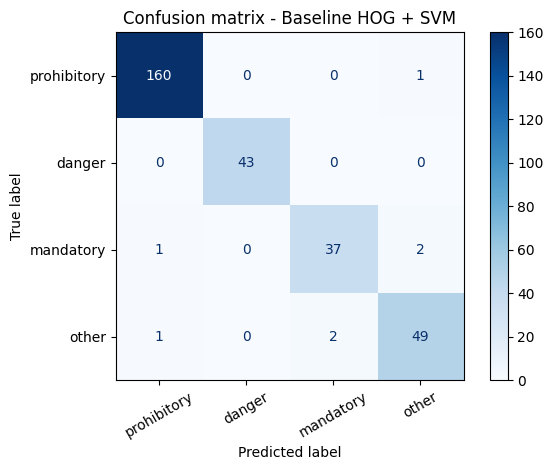

In [110]:
baseline_result = evaluate_hog_svm_config(
    model="Baseline HOG + SVM",
    role="baseline chính",
    config=DEFAULT_HOG_CONFIG,
)
baseline_table = result_table([baseline_result])
display(baseline_table[["model", "role", "accuracy", "macro_precision", "macro_recall", "macro_f1", "feature_dim"]])
baseline_macro_f1 = baseline_result["macro_f1"]
print(f"Baseline HOG + SVM mặc định đạt Macro F1 = {baseline_macro_f1:.4f}.")

cm = confusion_matrix(baseline_result["y_test"], baseline_result["y_pred"], labels=GROUP_ORDER)
ConfusionMatrixDisplay(cm, display_labels=GROUP_ORDER).plot(cmap="Blues", xticks_rotation=30)
plt.title("Confusion matrix - Baseline HOG + SVM")
plt.tight_layout()
plt.show()


## 6. Thiết kế cấu hình HOG tối ưu để kiểm tra giả thuyết chính

Phần này thiết kế cấu hình HOG theo hướng tuần tự. Mỗi bước chỉ thay đổi một tham số, quan sát trực quan HOG và kết quả Macro F1, sau đó giữ lại giá trị phù hợp nhất để làm nền cho bước tiếp theo.

Thứ tự thiết kế là: chọn `image_size`, sau đó chọn `pixels_per_cell` trên ROI size đã chọn, tiếp theo chọn `orientations`, cuối cùng chọn `cells_per_block`. Preprocessing được giữ cố định là `gray_clahe`.

Cách làm này là một quy trình demo có giải thích: dựa trên lý thuyết HOG, trực quan đặc trưng và Macro F1 để chốt cấu hình optimized. Cấu hình này sẽ được so sánh với baseline HOG + SVM để kiểm tra giả thuyết chính: tối ưu cấu hình HOG có cải thiện Macro F1 hay không.


In [111]:
def normalize_for_display(image):
    image = image.astype(np.float32)
    min_value = image.min()
    max_value = image.max()
    if max_value <= min_value:
        return np.zeros_like(image)
    return (image - min_value) / (max_value - min_value)


def hog_visualization_for_config(crop_rgb, config):
    hog_input = preprocess_for_hog(
        crop_rgb,
        image_size=normalize_tuple(config["image_size"]),
        preprocessing=config["preprocessing"],
    )
    feature_vector, hog_image = hog(
        hog_input,
        orientations=int(config["orientations"]),
        pixels_per_cell=normalize_tuple(config["pixels_per_cell"]),
        cells_per_block=normalize_tuple(config["cells_per_block"]),
        block_norm=config["block_norm"],
        visualize=True,
        feature_vector=True,
    )
    return hog_input, feature_vector, normalize_for_display(hog_image)


section6_visual_row = df[df["filename"].isin(test_files)].reset_index(drop=True).iloc[0]
section6_visual_image = read_image(DATA_ROOT / section6_visual_row["filename"])
section6_visual_crop = crop_box(
    section6_visual_image,
    (
        section6_visual_row["xmin"],
        section6_visual_row["ymin"],
        section6_visual_row["xmax"],
        section6_visual_row["ymax"],
    ),
)


def plot_hog_parameter_variants(section_title, variants):
    fig, axes = plt.subplots(2, len(variants) + 1, figsize=(4.0 * (len(variants) + 1), 6))
    axes[0, 0].imshow(section6_visual_crop)
    axes[0, 0].set_title(f"ROI gốc\nlabel={section6_visual_row['label_group']}")
    axes[0, 0].axis("off")
    axes[1, 0].axis("off")
    axes[1, 0].text(
        0.5,
        0.5,
        "Minh họa HOG\ntheo cấu hình\ncủa từng bước tối ưu",
        ha="center",
        va="center",
        fontsize=11,
    )

    for col_idx, (label, config) in enumerate(variants, start=1):
        hog_input, feature_vector, hog_image = hog_visualization_for_config(section6_visual_crop, config)
        axes[0, col_idx].imshow(hog_input, cmap="gray")
        axes[0, col_idx].set_title(label)
        axes[0, col_idx].axis("off")
        axes[1, col_idx].imshow(hog_image, cmap="magma")
        axes[1, col_idx].set_title(f"HOG image\nfeature_dim={len(feature_vector)}")
        axes[1, col_idx].axis("off")

    fig.suptitle(section_title, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


### 6.1 ROI size

ROI size ảnh hưởng đến lượng chi tiết được giữ lại trước khi tính HOG. ROI quá nhỏ có thể làm mất chi tiết ký hiệu bên trong biển báo, trong khi ROI quá lớn làm vector đặc trưng dài hơn và có thể tăng nhiễu.


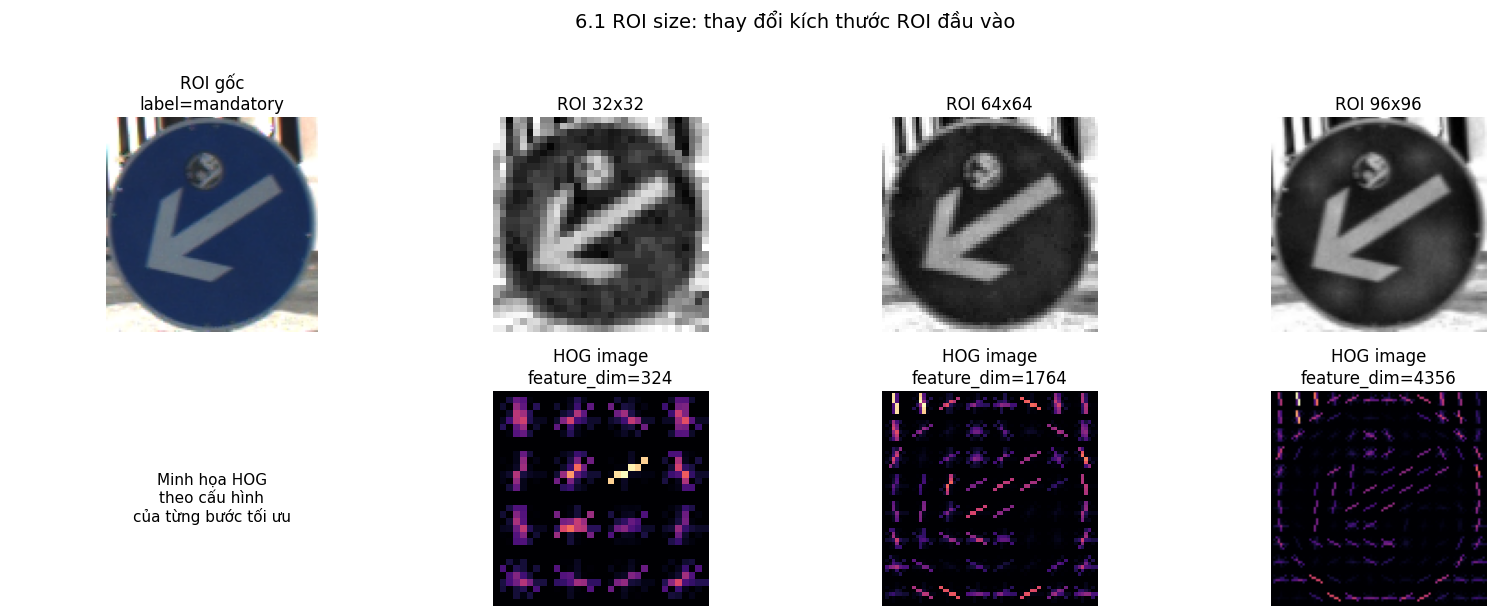

In [112]:
roi_visual_variants = [
    ("ROI 32x32", make_hog_config(image_size=(32, 32))),
    ("ROI 64x64", make_hog_config(image_size=(64, 64))),
    ("ROI 96x96", make_hog_config(image_size=(96, 96))),
]
plot_hog_parameter_variants("6.1 ROI size: thay đổi kích thước ROI đầu vào", roi_visual_variants)


Extract ROI features: 100%|██████████| 1213/1213 [00:07<00:00, 164.75it/s]


,image_size,macro_f1,feature_dim,accuracy,macro_precision,macro_recall
0,"(32, 32)",0.912744,324,0.932432,0.914857,0.911467
1,"(64, 64)",0.967432,1764,0.976351,0.969670,0.965274
2,"(96, 96)",0.991327,4356,0.993243,0.989095,0.993640


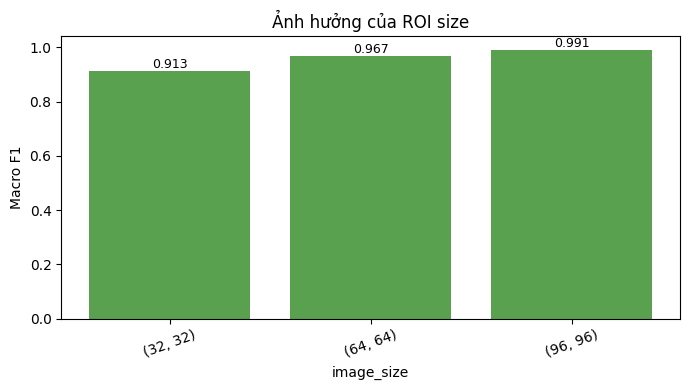

Chọn ROI size = (96, 96) với Macro F1 = 0.9913.


In [113]:
roi_results = []
for size in [(32, 32), (64, 64), (96, 96)]:
    config = make_hog_config(image_size=size)
    roi_results.append(evaluate_hog_svm_config("HOG + SVM", "ROI size sweep", config))
roi_sweep = result_table(roi_results)
display(roi_sweep[["image_size", "macro_f1", "feature_dim", "accuracy", "macro_precision", "macro_recall"]])
plot_macro_f1(roi_sweep, "image_size", "Ảnh hưởng của ROI size")
best_roi = roi_sweep.sort_values("macro_f1", ascending=False).iloc[0]
selected_image_size = normalize_tuple(best_roi["image_size"])
print(f"Chọn ROI size = {selected_image_size} với Macro F1 = {best_roi['macro_f1']:.4f}.")


### 6.2 pixels_per_cell

Sau khi chọn ROI size tốt nhất ở bước 6.1, bước này cố định ROI size đó và chỉ thay đổi `pixels_per_cell`. Tham số này quyết định độ chi tiết của HOG. Cell nhỏ giúp bắt chi tiết nhỏ như số, mũi tên và viền biển báo, nhưng có thể làm feature dài và nhạy với nhiễu. Cell lớn mô tả thô hơn, ít nhiễu hơn nhưng có thể bỏ mất chi tiết.


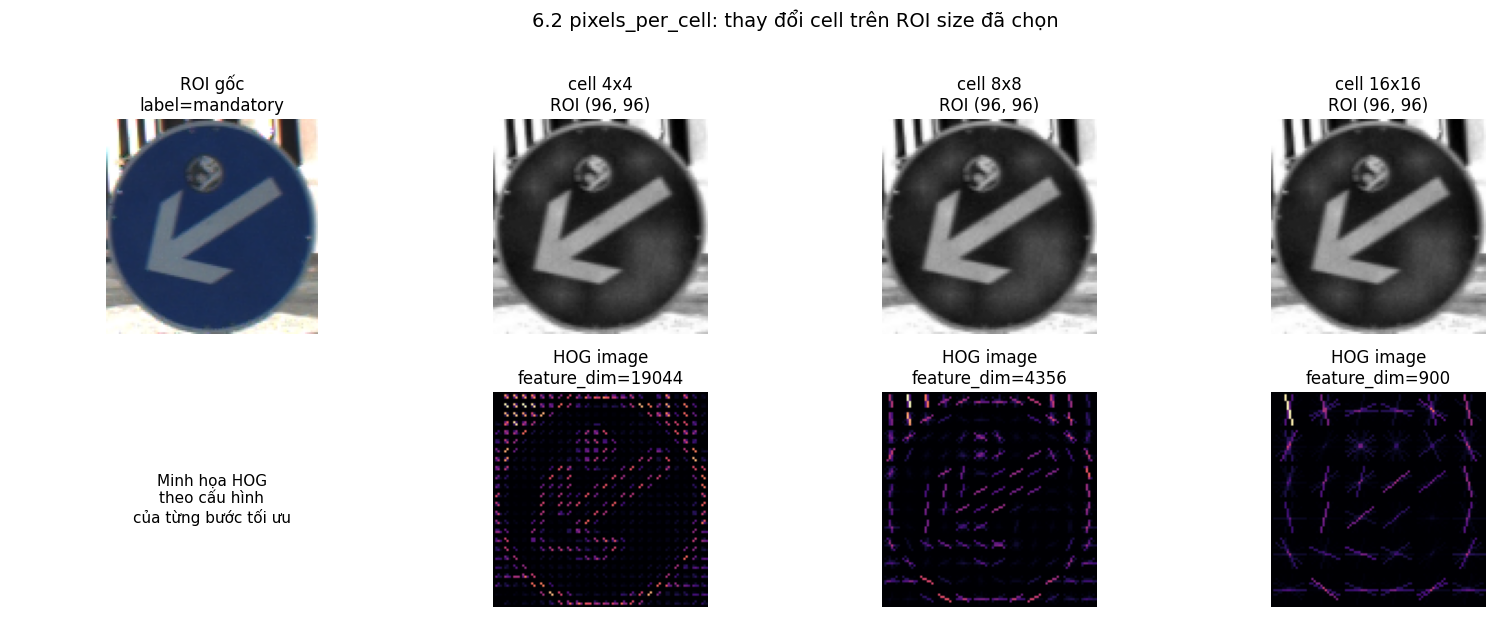

In [114]:
selected_image_size = normalize_tuple(best_roi["image_size"])
ppc_visual_variants = [
    (f"cell 4x4\nROI {selected_image_size}", make_hog_config(image_size=selected_image_size, pixels_per_cell=(4, 4))),
    (f"cell 8x8\nROI {selected_image_size}", make_hog_config(image_size=selected_image_size, pixels_per_cell=(8, 8))),
    (f"cell 16x16\nROI {selected_image_size}", make_hog_config(image_size=selected_image_size, pixels_per_cell=(16, 16))),
]
plot_hog_parameter_variants("6.2 pixels_per_cell: thay đổi cell trên ROI size đã chọn", ppc_visual_variants)


Extract ROI features: 100%|██████████| 1213/1213 [00:06<00:00, 197.40it/s]


,image_size,pixels_per_cell,macro_f1,feature_dim,accuracy,macro_precision,macro_recall
0,"(96, 96)","(4, 4)",0.972564,19044,0.983108,0.971642,0.974519
1,"(96, 96)","(8, 8)",0.991327,4356,0.993243,0.989095,0.993640
2,"(96, 96)","(16, 16)",0.964165,900,0.976351,0.963375,0.965274


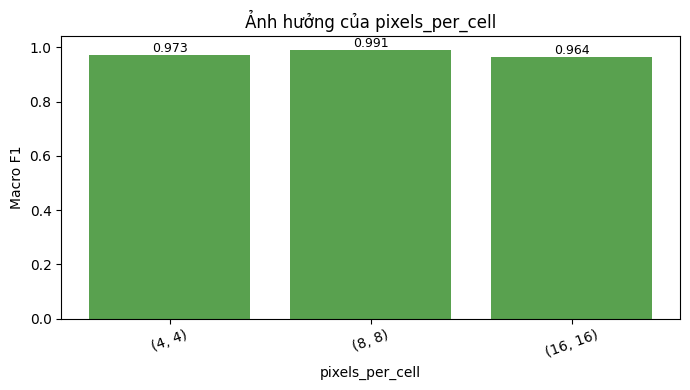

Với ROI size (96, 96), chọn pixels_per_cell = (8, 8) với Macro F1 = 0.9913.


In [115]:
selected_image_size = normalize_tuple(best_roi["image_size"])
ppc_results = []
for ppc in [(4, 4), (8, 8), (16, 16)]:
    config = make_hog_config(image_size=selected_image_size, pixels_per_cell=ppc)
    ppc_results.append(evaluate_hog_svm_config("HOG + SVM", "pixels_per_cell sweep", config))
ppc_sweep = result_table(ppc_results)
display(ppc_sweep[["image_size", "pixels_per_cell", "macro_f1", "feature_dim", "accuracy", "macro_precision", "macro_recall"]])
plot_macro_f1(ppc_sweep, "pixels_per_cell", "Ảnh hưởng của pixels_per_cell")
best_ppc = ppc_sweep.sort_values("macro_f1", ascending=False).iloc[0]
selected_pixels_per_cell = normalize_tuple(best_ppc["pixels_per_cell"])
print(f"Với ROI size {selected_image_size}, chọn pixels_per_cell = {selected_pixels_per_cell} với Macro F1 = {best_ppc['macro_f1']:.4f}.")


### 6.3 orientations

Sau khi cố định ROI size và `pixels_per_cell` đã chọn, bước này chỉ thay đổi `orientations`. `orientations` là số bin hướng gradient. Số bin ít làm đặc trưng gọn và ổn định hơn, nhưng mô tả hướng cạnh thô hơn. Số bin nhiều mô tả hướng cạnh chi tiết hơn, nhưng có thể làm histogram thưa và nhạy với nhiễu.


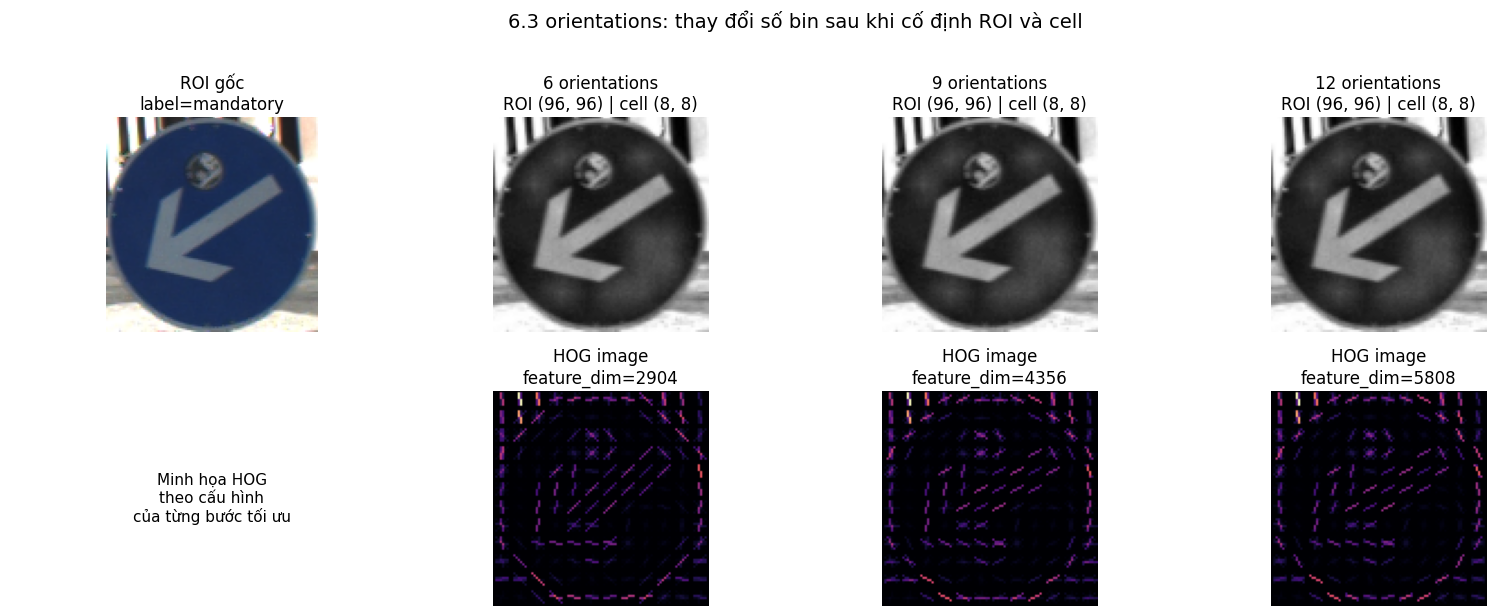

In [116]:
selected_image_size = normalize_tuple(best_roi["image_size"])
selected_pixels_per_cell = normalize_tuple(best_ppc["pixels_per_cell"])
orientation_visual_variants = [
    (f"6 orientations\nROI {selected_image_size} | cell {selected_pixels_per_cell}", make_hog_config(image_size=selected_image_size, pixels_per_cell=selected_pixels_per_cell, orientations=6)),
    (f"9 orientations\nROI {selected_image_size} | cell {selected_pixels_per_cell}", make_hog_config(image_size=selected_image_size, pixels_per_cell=selected_pixels_per_cell, orientations=9)),
    (f"12 orientations\nROI {selected_image_size} | cell {selected_pixels_per_cell}", make_hog_config(image_size=selected_image_size, pixels_per_cell=selected_pixels_per_cell, orientations=12)),
]
plot_hog_parameter_variants("6.3 orientations: thay đổi số bin sau khi cố định ROI và cell", orientation_visual_variants)


Extract ROI features: 100%|██████████| 1213/1213 [00:07<00:00, 164.92it/s]


,image_size,pixels_per_cell,orientations,macro_f1,feature_dim,accuracy,macro_precision,macro_recall
0,"(96, 96)","(8, 8)",6,0.971646,2904,0.979730,0.973262,0.970082
1,"(96, 96)","(8, 8)",9,0.991327,4356,0.993243,0.989095,0.993640
2,"(96, 96)","(8, 8)",12,0.985842,5808,0.989865,0.983193,0.988832


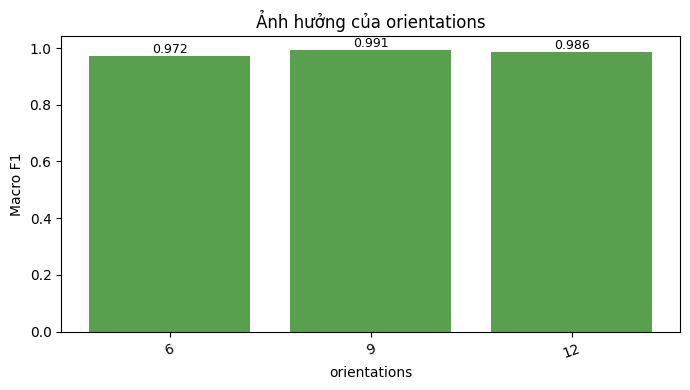

Với ROI size (96, 96) và pixels_per_cell (8, 8), chọn orientations = 9 với Macro F1 = 0.9913.


In [117]:
selected_image_size = normalize_tuple(best_roi["image_size"])
selected_pixels_per_cell = normalize_tuple(best_ppc["pixels_per_cell"])
orientation_results = []
for orientations in [6, 9, 12]:
    config = make_hog_config(
        image_size=selected_image_size,
        pixels_per_cell=selected_pixels_per_cell,
        orientations=orientations,
    )
    orientation_results.append(evaluate_hog_svm_config("HOG + SVM", "orientations sweep", config))
orientation_sweep = result_table(orientation_results)
display(orientation_sweep[["image_size", "pixels_per_cell", "orientations", "macro_f1", "feature_dim", "accuracy", "macro_precision", "macro_recall"]])
plot_macro_f1(orientation_sweep, "orientations", "Ảnh hưởng của orientations")
best_orientation = orientation_sweep.sort_values("macro_f1", ascending=False).iloc[0]
selected_orientations = int(best_orientation["orientations"])
print(f"Với ROI size {selected_image_size} và pixels_per_cell {selected_pixels_per_cell}, chọn orientations = {selected_orientations} với Macro F1 = {best_orientation['macro_f1']:.4f}.")


### 6.4 cells_per_block

Sau khi cố định ROI size, `pixels_per_cell` và `orientations`, bước cuối chỉ thay đổi `cells_per_block`. Tham số này ảnh hưởng đến cách chuẩn hóa cục bộ của HOG. Block lớn hơn có thể giúp đặc trưng ổn định hơn với thay đổi sáng/tối, nhưng cũng làm feature dài hơn.


In [118]:
selected_image_size = normalize_tuple(best_roi["image_size"])
selected_pixels_per_cell = normalize_tuple(best_ppc["pixels_per_cell"])
selected_orientations = int(best_orientation["orientations"])
cpb_visual_variants = [
    (f"block 1x1 cell\nROI {selected_image_size} | cell {selected_pixels_per_cell} | {selected_orientations} bins", make_hog_config(image_size=selected_image_size, pixels_per_cell=selected_pixels_per_cell, orientations=selected_orientations, cells_per_block=(1, 1))),
    (f"block 2x2 cell\nROI {selected_image_size} | cell {selected_pixels_per_cell} | {selected_orientations} bins", make_hog_config(image_size=selected_image_size, pixels_per_cell=selected_pixels_per_cell, orientations=selected_orientations, cells_per_block=(2, 2))),
    (f"block 3x3 cell\nROI {selected_image_size} | cell {selected_pixels_per_cell} | {selected_orientations} bins", make_hog_config(image_size=selected_image_size, pixels_per_cell=selected_pixels_per_cell, orientations=selected_orientations, cells_per_block=(3, 3))),
]


Extract ROI features: 100%|██████████| 1213/1213 [00:07<00:00, 172.53it/s]


,image_size,pixels_per_cell,orientations,cells_per_block,macro_f1,feature_dim,accuracy,macro_precision,macro_recall
0,"(96, 96)","(8, 8)",9,"(1, 1)",0.949621,1296,0.966216,0.954195,0.946524
1,"(96, 96)","(8, 8)",9,"(2, 2)",0.991327,4356,0.993243,0.989095,0.993640
2,"(96, 96)","(8, 8)",9,"(3, 3)",0.991340,8100,0.993243,0.990741,0.992197


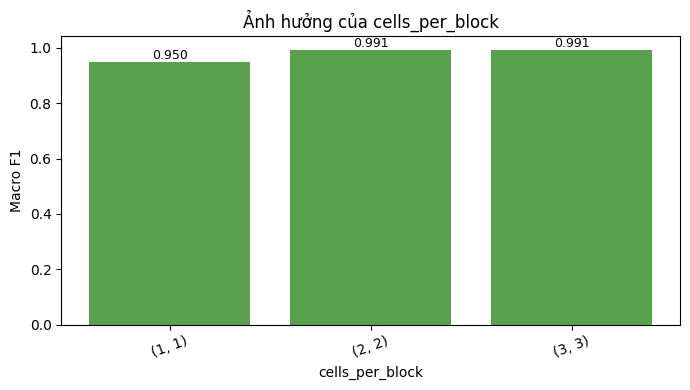

In [ ]:
selected_image_size = normalize_tuple(best_roi["image_size"])
selected_pixels_per_cell = normalize_tuple(best_ppc["pixels_per_cell"])
selected_orientations = int(best_orientation["orientations"])
cpb_results = []
for cpb in [(1, 1), (2, 2), (3, 3)]:
    config = make_hog_config(
        image_size=selected_image_size,
        pixels_per_cell=selected_pixels_per_cell,
        orientations=selected_orientations,
        cells_per_block=cpb,
    )
    cpb_results.append(evaluate_hog_svm_config("HOG + SVM", "cells_per_block sweep", config))
cpb_sweep = result_table(cpb_results)
display(cpb_sweep[["image_size", "pixels_per_cell", "orientations", "cells_per_block", "macro_f1", "feature_dim", "accuracy", "macro_precision", "macro_recall"]])
plot_macro_f1(cpb_sweep, "cells_per_block", "Ảnh hưởng của cells_per_block")
best_cpb = cpb_sweep.sort_values("macro_f1", ascending=False).iloc[0]

## 7. Tổng hợp quy trình tuần tự và chốt cấu hình HOG tối ưu

Phần 7 tổng hợp lại quy trình thiết kế ở phần 6. Các tham số HOG không hoàn toàn độc lập: `image_size` quyết định lưới cell, `pixels_per_cell` làm thay đổi số cell/block, còn `cells_per_block` chuẩn hóa trên lưới cell đó. Vì vậy, một giá trị tốt trên cấu hình cũ chưa chắc vẫn tốt khi các tham số trước đã thay đổi.

Do đó nhóm dùng cách tối ưu tuần tự: sau mỗi bước, giá trị được chọn sẽ làm nền cho bước tiếp theo. Cách này không phải grid search toàn bộ, nhưng phù hợp với mục tiêu demo: giải thích vai trò của từng tham số bằng lý thuyết HOG, hình ảnh trực quan và Macro F1.

Từ `6.1 ROI size`, nhóm chọn `image_size=(96, 96)`. Về lý thuyết, ROI lớn hơn giữ được nhiều chi tiết hình học của biển báo trước khi tính gradient. Trên hình trực quan, ROI `32x32` làm cấu trúc HOG bị nén và mất nhiều chi tiết nhỏ; ROI `64x64` đã tốt hơn nhưng vẫn ít cell hơn; ROI `96x96` cho cấu trúc cạnh rõ hơn và Macro F1 cao nhất trong các ROI size được thử.

Từ `6.2 pixels_per_cell`, trên ROI `96x96`, nhóm chọn `pixels_per_cell=(8, 8)`. Về lý thuyết, cell quá nhỏ như `4x4` tạo lưới HOG rất dày, bắt được nhiều chi tiết nhưng dễ nhạy với nhiễu và làm feature dimension tăng. Cell quá lớn như `16x16` làm HOG thô hơn, các cạnh nhỏ bên trong biển báo dễ bị gộp mất. Trên hình trực quan, `8x8` giữ được viền và cấu trúc ký hiệu rõ hơn `16x16`, nhưng không dày và nhiễu như `4x4`. Vì vậy `8x8` là điểm cân bằng tốt nhất giữa Macro F1 và độ phức tạp đặc trưng.

Từ `6.3 orientations`, trên nền `96x96 + cell 8x8`, nhóm chọn `orientations=9`. Về lý thuyết, HOG unsigned gradient dùng miền hướng `0-180°`; nếu số bin quá ít như `6`, mỗi bin quá rộng nên hướng cạnh bị mô tả thô. Nếu tăng lên `12`, histogram chi tiết hơn nhưng dễ thưa và nhạy với nhiễu. Trên hình trực quan, `9 orientations` cho các hướng cạnh đủ rõ mà không làm biểu diễn bị chia nhỏ quá mức. Do đó `9` là lựa chọn cân bằng hơn so với `6` và `12`.

Từ `6.4 cells_per_block`, trên nền `96x96 + cell 8x8 + 9 orientations`, nhóm chọn `cells_per_block=(2, 2)`. Về lý thuyết, block `1x1` chỉ chuẩn hóa trên từng cell riêng lẻ nên ít tận dụng được ngữ cảnh lân cận, dễ bị ảnh hưởng thay đổi sáng/tối; block `3x3` gom vùng lớn hơn, có thể ổn định hơn nhưng làm feature dimension tăng mạnh và có nguy cơ làm giảm tính cục bộ của đặc trưng cạnh. Trong split hiện tại, `cells_per_block=(3, 3)` có Macro F1 nhỉnh hơn rất nhỏ, nhưng nhóm vẫn chọn `2x2` vì mức chênh lệch không đáng kể so với chi phí feature dimension và độ phức tạp tăng thêm.

Vì vậy, cấu hình optimized được chốt là: `image_size=(96, 96)`, `orientations=9`, `pixels_per_cell=(8, 8)`, `cells_per_block=(2, 2)`, `preprocessing=gray_clahe`. Trên split hiện tại, cấu hình này đạt Macro F1 khoảng `0.9913`, cao hơn baseline (`0.9674`), trong khi feature dimension vẫn ở mức phù hợp cho demo ROI classification.


In [120]:
optimized_config = make_hog_config(
    image_size=(96, 96),
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
)
optimized_result = evaluate_hog_svm_config(
    "Optimized HOG + SVM",
    "cấu hình tối ưu từ phần 6",
    optimized_config,
)

final_comparison = result_table([baseline_result, optimized_result])
final_comparison["delta_vs_baseline"] = final_comparison["macro_f1"] - baseline_result["macro_f1"]
display(final_comparison[[
    "model",
    "role",
    "image_size",
    "orientations",
    "pixels_per_cell",
    "cells_per_block",
    "preprocessing",
    "accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "delta_vs_baseline",
    "feature_dim",
]])

delta_optimized = optimized_result["macro_f1"] - baseline_result["macro_f1"]
print("Chốt Optimized HOG + SVM theo kết luận lý thuyết và trực quan ở phần 6.")
print(f"Optimized HOG + SVM Macro F1 = {optimized_result['macro_f1']:.4f}.")
print(f"Baseline HOG + SVM Macro F1 = {baseline_result['macro_f1']:.4f}.")
print(f"Delta Macro F1 = {delta_optimized:+.4f}.")


,model,role,image_size,orientations,pixels_per_cell,cells_per_block,preprocessing,accuracy,macro_precision,macro_recall,macro_f1,delta_vs_baseline,feature_dim
0,Baseline HOG + SVM,baseline chính,"(64, 64)",9,"(8, 8)","(2, 2)",gray_clahe,0.976351,0.969670,0.965274,0.967432,0.000000,1764
1,Optimized HOG + SVM,cấu hình tối ưu từ phần 6,"(96, 96)",9,"(8, 8)","(2, 2)",gray_clahe,0.993243,0.989095,0.993640,0.991327,0.023895,4356


Chốt Optimized HOG + SVM theo kết luận lý thuyết và trực quan ở phần 6.
Optimized HOG + SVM Macro F1 = 0.9913.
Baseline HOG + SVM Macro F1 = 0.9674.
Delta Macro F1 = +0.0239.


Kết quả ủng hộ kết luận: cấu hình HOG tối ưu cải thiện Macro F1 so với baseline.

### Khảo sát phụ tham số SVM: regularization `C`

Phần này chỉ là khảo sát phụ cho kỹ thuật Linear SVM, không dùng để chọn lại optimized model. Kết luận chính của notebook vẫn là: tối ưu cấu hình HOG giúp cải thiện Macro F1 so với baseline.

Để cô lập ảnh hưởng của SVM, ta cố định:

- preprocessing = `gray_clahe`
- HOG = cấu hình optimized đã chốt ở phần 7

Sau đó chỉ thay đổi `C` của Linear SVM. Khác với preprocessing hoặc HOG, SVM không biến đổi ảnh ROI; nó nhận vector HOG và thay đổi cách học biên phân cách. Vì vậy, trực quan phù hợp ở đây là decision score theo từng lớp, không phải lặp lại ảnh ROI.

,C,accuracy,macro_precision,macro_recall,macro_f1,feature_dim
0,0.01,0.993243,0.989095,0.99364,0.991327,4356
1,0.10,0.993243,0.989095,0.99364,0.991327,4356
2,1.00,0.993243,0.989095,0.99364,0.991327,4356
3,10.00,0.993243,0.989095,0.99364,0.991327,4356


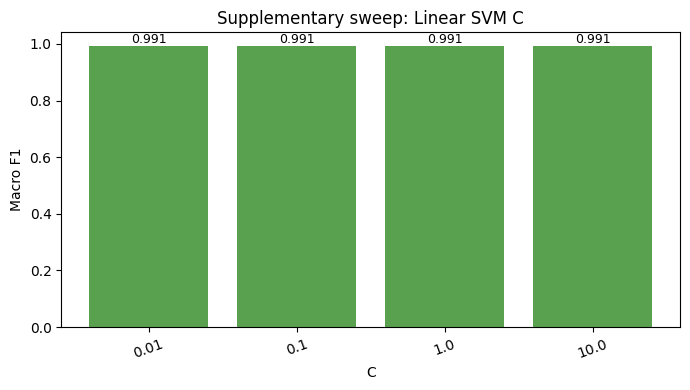

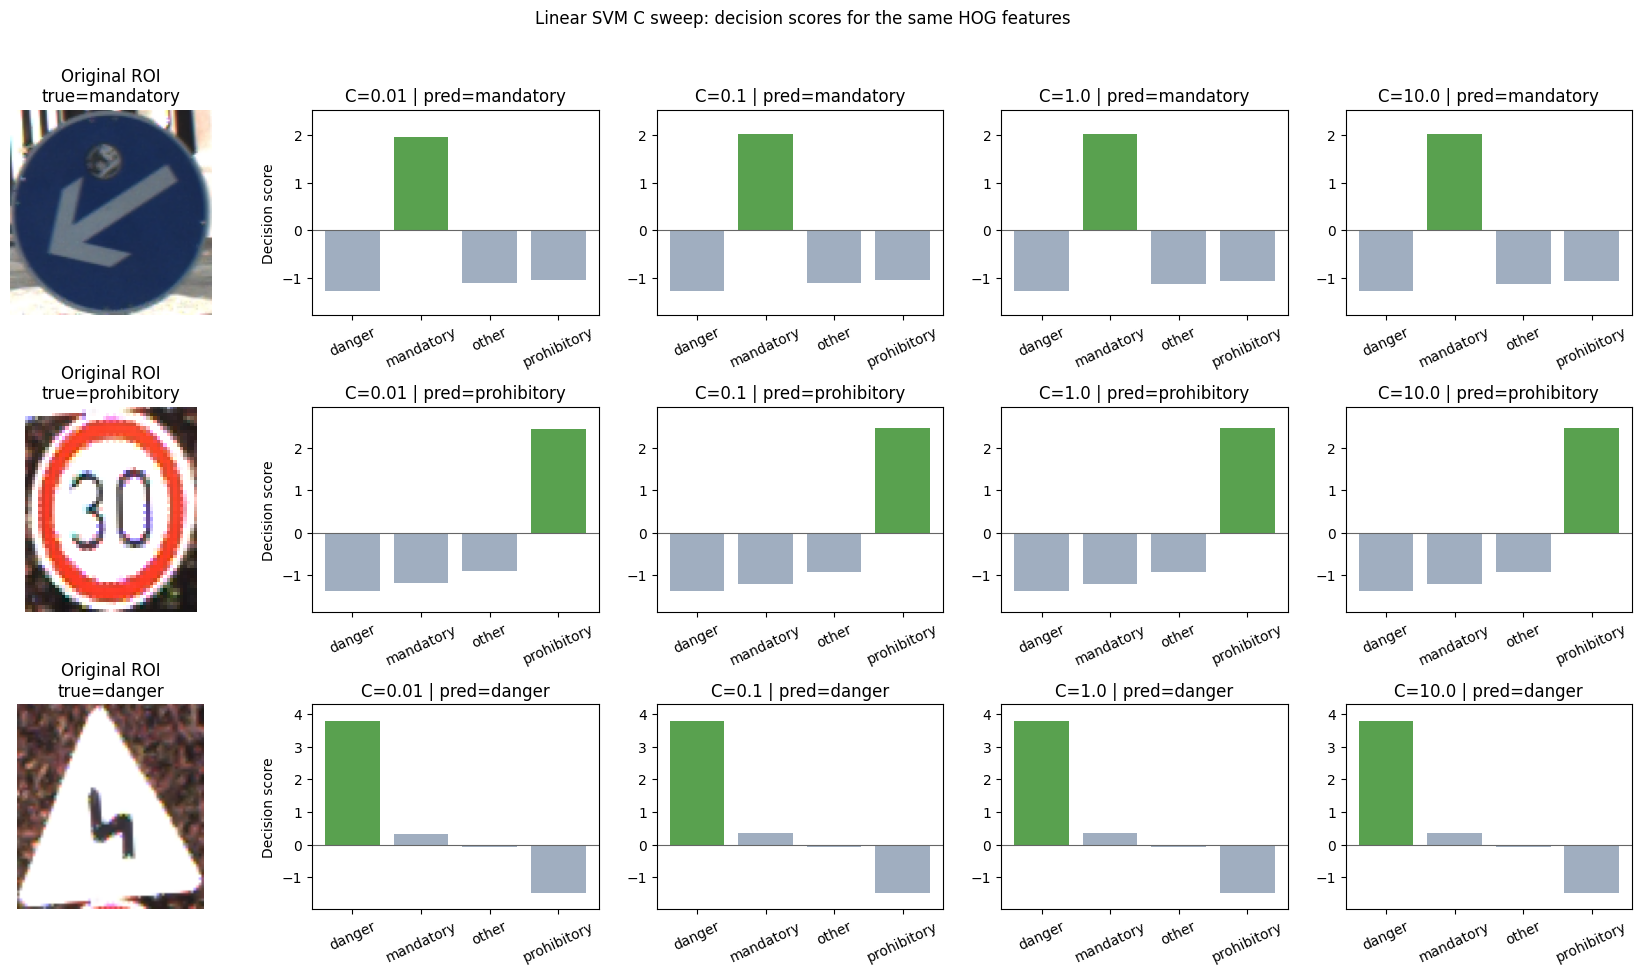

In [121]:
SVM_C_SWEEP_VALUES = [0.01, 0.1, 1.0, 10.0]

svm_sweep_results = []
for C_value in SVM_C_SWEEP_VALUES:
    result = evaluate_hog_svm_config(
        model="Optimized HOG + Linear SVM",
        role=f"supplementary SVM C={C_value}",
        config=optimized_config,
        C=C_value,
    )
    result["C"] = C_value
    svm_sweep_results.append(result)

svm_sweep = pd.DataFrame([
    {
        "C": result["C"],
        "accuracy": result["accuracy"],
        "macro_precision": result["macro_precision"],
        "macro_recall": result["macro_recall"],
        "macro_f1": result["macro_f1"],
        "feature_dim": result["feature_dim"],
    }
    for result in svm_sweep_results
])
display(svm_sweep)
plot_macro_f1(svm_sweep, "C", "Supplementary sweep: Linear SVM C")

svm_visual_samples = df[df["filename"].isin(test_files)].reset_index(drop=True).head(3)
fig, axes = plt.subplots(
    len(svm_visual_samples),
    len(SVM_C_SWEEP_VALUES) + 1,
    figsize=(3.4 * (len(SVM_C_SWEEP_VALUES) + 1), 3.2 * len(svm_visual_samples)),
)
if len(svm_visual_samples) == 1:
    axes = np.array([axes])

for row_idx, (_, row) in enumerate(svm_visual_samples.iterrows()):
    image = read_image(DATA_ROOT / row["filename"])
    crop = crop_box(image, (row["xmin"], row["ymin"], row["xmax"], row["ymax"]))
    feature = extract_feature_from_crop(crop, optimized_config).reshape(1, -1)
    true_label = row["label_group"]

    axes[row_idx, 0].imshow(crop)
    axes[row_idx, 0].set_title(f"Original ROI\ntrue={true_label}")
    axes[row_idx, 0].axis("off")

    score_values = []
    for result in svm_sweep_results:
        scores = result["classifier"].decision_function(feature).reshape(-1)
        score_values.extend(scores.tolist())
    y_min = min(score_values) - 0.5
    y_max = max(score_values) + 0.5

    for col_idx, result in enumerate(svm_sweep_results, start=1):
        clf = result["classifier"]
        scores = clf.decision_function(feature).reshape(-1)
        classes = list(clf.classes_)
        pred = clf.predict(feature)[0]
        colors = ["#59A14F" if cls == pred else "#A0AEC0" for cls in classes]
        if true_label in classes and pred != true_label:
            colors[classes.index(true_label)] = "#F28E2B"

        axes[row_idx, col_idx].bar(classes, scores, color=colors)
        axes[row_idx, col_idx].axhline(0, color="#666666", linewidth=0.8)
        axes[row_idx, col_idx].set_ylim(y_min, y_max)
        axes[row_idx, col_idx].set_title(f"C={result['C']} | pred={pred}")
        axes[row_idx, col_idx].tick_params(axis="x", rotation=25)
        if col_idx == 1:
            axes[row_idx, col_idx].set_ylabel("Decision score")

plt.suptitle("Linear SVM C sweep: decision scores for the same HOG features", y=1.01)
plt.tight_layout()
plt.show()

best_svm_c = svm_sweep.sort_values("macro_f1", ascending=False).iloc[0]

Lưu ý: Phần sweep `C` chỉ dùng để quan sát ảnh hưởng của tham số SVM. Nhóm không dùng kết quả này để định nghĩa lại optimized model; optimized cuối vẫn được chốt theo cấu hình HOG ở phần 7.

Trong khảo sát phụ SVM, Macro F1 gần như không thay đổi khi `C` thay đổi từ `0.01` đến `10.0`. Điều này cho thấy trên bộ đặc trưng HOG đã tối ưu, dữ liệu test hiện tại đã được phân tách khá ổn bởi Linear SVM. Vì vậy, thay đổi mức regularization của SVM trong khoảng này không làm thay đổi đáng kể quyết định phân loại cuối cùng.

Nói cách khác, khi vector HOG đã đủ tốt, vai trò chính nằm ở chất lượng đặc trưng đầu vào hơn là việc tinh chỉnh mạnh tham số `C` của SVM. `C` có thể làm thay đổi decision score hoặc độ rộng biên phân cách, nhưng nếu thứ tự lớp có score cao nhất không đổi thì nhãn dự đoán không đổi, dẫn đến Macro F1 giữ nguyên.

Kết quả này củng cố hướng chính của nhóm: cải thiện hiệu năng chủ yếu đến từ tối ưu cấu hình HOG, còn sweep `C` của SVM chỉ là khảo sát phụ và không được dùng để định nghĩa lại optimized model.

## 8. Kiểm chứng trực quan sau khi chốt cấu hình HOG tối ưu

Phần này so sánh trực quan Baseline HOG + SVM và Optimized HOG + SVM trên một số ROI test. 
Mục tiêu là quan sát cấu hình optimized sau khi chốt ở phần 7 biểu diễn cạnh/gradient khác baseline như thế nào, đặc biệt ở các mẫu baseline dự đoán sai nhưng optimized dự đoán đúng.

In [122]:
hog_config_comparison = pd.DataFrame([
    {
        "model": "Baseline HOG + SVM",
        "image_size": baseline_result["image_size"],
        "pixels_per_cell": baseline_result["pixels_per_cell"],
        "cells_per_block": baseline_result["cells_per_block"],
        "preprocessing": baseline_result["preprocessing"],
        "orientations": baseline_result["orientations"],
        "feature_dim": baseline_result["feature_dim"],
        "macro_f1": baseline_result["macro_f1"],
    },
    {
        "model": "Optimized HOG + SVM",
        "image_size": optimized_result["image_size"],
        "pixels_per_cell": optimized_result["pixels_per_cell"],
        "cells_per_block": optimized_result["cells_per_block"],
        "preprocessing": optimized_result["preprocessing"],
        "orientations": optimized_result["orientations"],
        "feature_dim": optimized_result["feature_dim"],
        "macro_f1": optimized_result["macro_f1"],
    },
])
display(hog_config_comparison)


,model,image_size,pixels_per_cell,cells_per_block,preprocessing,orientations,feature_dim,macro_f1
0,Baseline HOG + SVM,"(64, 64)","(8, 8)","(2, 2)",gray_clahe,9,1764,0.967432
1,Optimized HOG + SVM,"(96, 96)","(8, 8)","(2, 2)",gray_clahe,9,4356,0.991327


Trong `random_state=126`, preprocessing được cố định là `gray_clahe`. Cấu hình optimized cuối được chốt từ quy trình tối ưu tuần tự ở phần 6: `image_size=(96, 96)`, `pixels_per_cell=(8, 8)`, `orientations=9` và `cells_per_block=(2, 2)`.

Với split hiện tại, baseline đạt Macro F1 khoảng `0.9674`, còn optimized đạt khoảng `0.9913`, tăng khoảng `+0.0239`. Kết quả này ủng hộ giả thuyết chính: tối ưu cấu hình HOG giúp cải thiện Macro F1 so với baseline HOG + SVM mặc định trong thiết lập classification trên ROI crop.

,filename,class_id,true_label,baseline_pred,optimized_pred
6,00025.ppm,40,mandatory,other,mandatory
58,00162.ppm,17,other,mandatory,other
106,00295.ppm,6,other,prohibitory,other


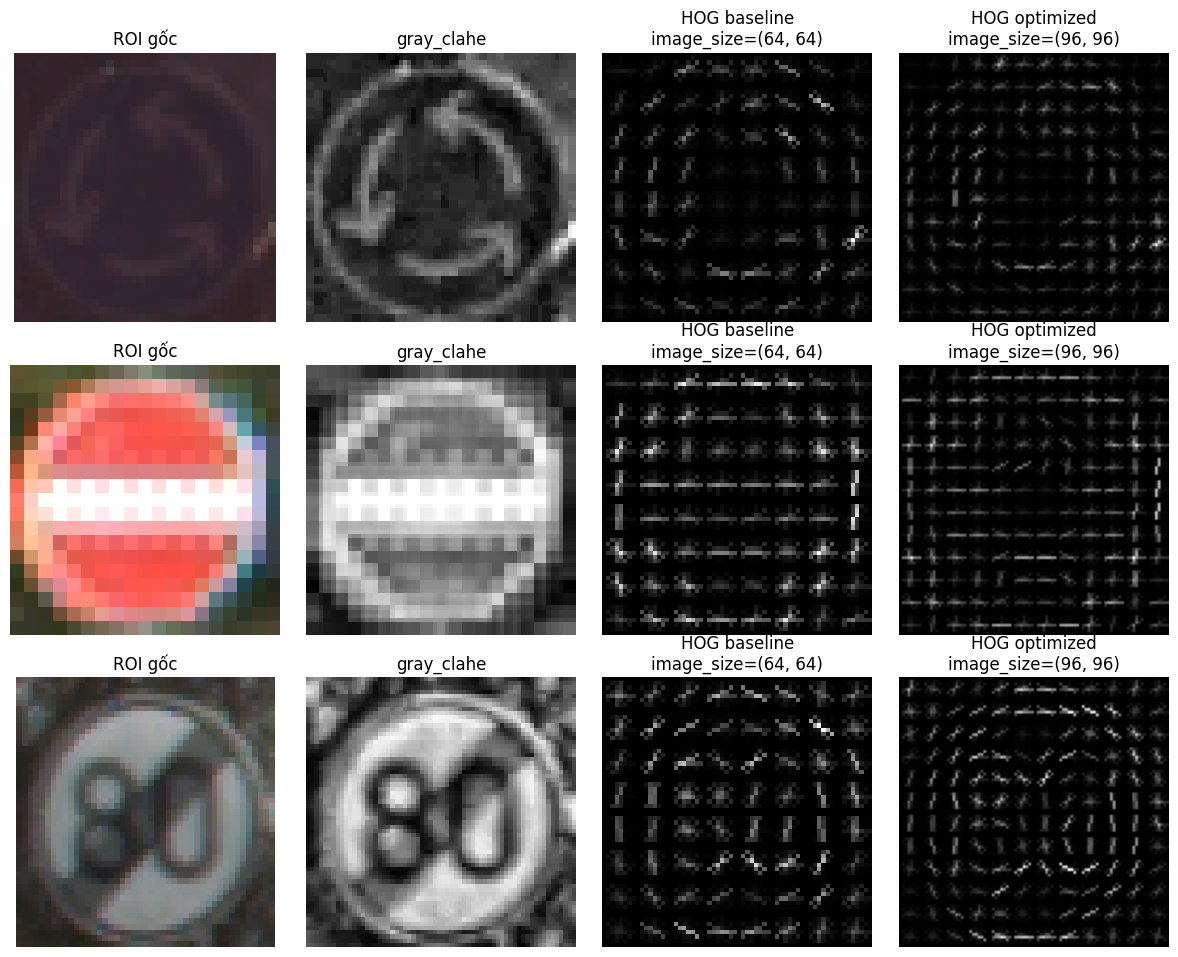

In [123]:
visual_test_df = df[df["filename"].isin(test_files)].reset_index(drop=True).copy()
visual_test_df["true_label"] = baseline_result["y_test"]
visual_test_df["baseline_pred"] = baseline_result["y_pred"]
visual_test_df["optimized_pred"] = optimized_result["y_pred"]

baseline_wrong_optimized_correct = visual_test_df[
    (visual_test_df["baseline_pred"] != visual_test_df["true_label"])
    & (visual_test_df["optimized_pred"] == visual_test_df["true_label"])
].copy()

selected_indices = []

mandatory_fixed = baseline_wrong_optimized_correct[baseline_wrong_optimized_correct["true_label"] == "mandatory"]
if len(mandatory_fixed) > 0:
    selected_indices.extend(mandatory_fixed.index.tolist()[:1])

for idx in baseline_wrong_optimized_correct.index:
    if idx not in selected_indices:
        selected_indices.append(idx)
    if len(selected_indices) >= 3:
        break

if len(selected_indices) < 3:
    for label in ["mandatory"] + GROUP_ORDER:
        label_samples = visual_test_df[visual_test_df["true_label"] == label]
        for idx in label_samples.index:
            if idx not in selected_indices:
                selected_indices.append(idx)
                break
        if len(selected_indices) >= 3:
            break

if len(selected_indices) < 3:
    for idx in visual_test_df.index:
        if idx not in selected_indices:
            selected_indices.append(idx)
        if len(selected_indices) >= 3:
            break

selected_samples = visual_test_df.loc[selected_indices[:3]].copy()
display(selected_samples[["filename", "class_id", "true_label", "baseline_pred", "optimized_pred"]])


def normalize_for_display(image):
    image = image.astype(np.float32)
    lo, hi = image.min(), image.max()
    if hi - lo < 1e-8:
        return np.zeros_like(image)
    return (image - lo) / (hi - lo)


def hog_visualization(image_rgb, config):
    hog_input = preprocess_for_hog(
        image_rgb,
        image_size=normalize_tuple(config["image_size"]),
        preprocessing=config["preprocessing"],
    )
    _, hog_image = hog(
        hog_input,
        orientations=int(config["orientations"]),
        pixels_per_cell=normalize_tuple(config["pixels_per_cell"]),
        cells_per_block=normalize_tuple(config["cells_per_block"]),
        block_norm=config["block_norm"],
        visualize=True,
        feature_vector=True,
    )
    return hog_input, normalize_for_display(hog_image)


baseline_visual_config = make_hog_config(**DEFAULT_HOG_CONFIG)
optimized_visual_config = make_hog_config(**optimized_config)

fig, axes = plt.subplots(len(selected_samples), 4, figsize=(12, 3.2 * len(selected_samples)))
if len(selected_samples) == 1:
    axes = np.array([axes])

for row_idx, (_, row) in enumerate(selected_samples.iterrows()):
    image = read_image(DATA_ROOT / row["filename"])
    crop = crop_box(image, (row["xmin"], row["ymin"], row["xmax"], row["ymax"]))
    baseline_preprocessed, baseline_hog_vis = hog_visualization(crop, baseline_visual_config)
    _, optimized_hog_vis = hog_visualization(crop, optimized_visual_config)

    axes[row_idx, 0].imshow(crop)
    axes[row_idx, 0].set_title("ROI gốc")
    axes[row_idx, 1].imshow(baseline_preprocessed, cmap="gray")
    axes[row_idx, 1].set_title("gray_clahe")
    axes[row_idx, 2].imshow(baseline_hog_vis, cmap="gray")
    axes[row_idx, 2].set_title(f"HOG baseline\nimage_size={baseline_visual_config['image_size']}")
    axes[row_idx, 3].imshow(optimized_hog_vis, cmap="gray")
    axes[row_idx, 3].set_title(f"HOG optimized\nimage_size={optimized_visual_config['image_size']}")

    caption = (
        f"true_label={row['true_label']}\n"
        f"baseline_pred={row['baseline_pred']}\n"
        f"optimized_pred={row['optimized_pred']}"
    )
    axes[row_idx, 0].set_ylabel(caption, fontsize=9)
    for col in range(4):
        axes[row_idx, col].axis("off")

plt.tight_layout()
plt.show()


In [124]:
_, _, baseline_visual_f1, _ = precision_recall_fscore_support(
    baseline_result["y_test"],
    baseline_result["y_pred"],
    labels=GROUP_ORDER,
    average=None,
    zero_division=0,
)
_, _, optimized_visual_f1, _ = precision_recall_fscore_support(
    optimized_result["y_test"],
    optimized_result["y_pred"],
    labels=GROUP_ORDER,
    average=None,
    zero_division=0,
)

visual_per_class_delta = pd.DataFrame({
    "class": GROUP_ORDER,
    "baseline_f1": baseline_visual_f1,
    "optimized_f1": optimized_visual_f1,
})
visual_per_class_delta["delta_f1"] = visual_per_class_delta["optimized_f1"] - visual_per_class_delta["baseline_f1"]
display(visual_per_class_delta)

mandatory_row = visual_per_class_delta[visual_per_class_delta["class"] == "mandatory"]
if len(mandatory_row) > 0:
    mandatory_delta = mandatory_row["delta_f1"].iloc[0]
    print(f"Trong split hiện tại, lớp mandatory có delta F1 = {mandatory_delta:+.4f} khi dùng optimized HOG.")
    if mandatory_delta > 0:
        print("Lớp mandatory cải thiện rõ hơn khi dùng optimized HOG, nên các ví dụ mandatory là minh họa phù hợp cho sự thay đổi biểu diễn HOG.")


,class,baseline_f1,optimized_f1,delta_f1
0,prohibitory,0.990712,0.996885,0.006173
1,danger,1.000000,1.000000,0.000000
2,mandatory,0.936709,0.987654,0.050945
3,other,0.942308,0.980769,0.038462


Trong split hiện tại, lớp mandatory có delta F1 = +0.0509 khi dùng optimized HOG.
Lớp mandatory cải thiện rõ hơn khi dùng optimized HOG, nên các ví dụ mandatory là minh họa phù hợp cho sự thay đổi biểu diễn HOG.


Các hình HOG visualization không dùng để chứng minh tuyệt đối rằng một cấu hình HOG luôn tốt hơn cấu hình khác. Chúng dùng để minh họa sự khác biệt trong cách các cấu hình biểu diễn cạnh/gradient. Kết luận chính vẫn dựa trên so sánh Macro F1 giữa baseline và optimized, cùng với robustness benchmark.


## 9. Phân tích độ bền và lỗi sai của mô hình

Phần này nhằm đánh giá độ bền của Baseline HOG + SVM và Optimized HOG + SVM trong các điều kiện ảnh khó hơn. Vì HOG phụ thuộc vào gradient, các biến đổi như brightness, contrast, blur và noise có thể làm thay đổi vector HOG, từ đó ảnh hưởng đến dự đoán của SVM. Do đó robustness benchmark giúp đánh giá sâu hơn so với chỉ đo Macro F1 trên test sạch. Các biến đổi được áp dụng trực tiếp lên ROI của test set.

In [125]:
def transform_identity(image_rgb, idx=None):
    return image_rgb


def transform_low_brightness(image_rgb, idx=None):
    return np.clip(image_rgb.astype(np.float32) * 0.65, 0, 255).astype(np.uint8)


def transform_high_brightness(image_rgb, idx=None):
    return np.clip(image_rgb.astype(np.float32) * 1.25 + 10, 0, 255).astype(np.uint8)


def transform_low_contrast(image_rgb, idx=None):
    mean = np.array([127.5], dtype=np.float32)
    return np.clip((image_rgb.astype(np.float32) - mean) * 0.65 + mean, 0, 255).astype(np.uint8)


def transform_gaussian_blur(image_rgb, idx=None):
    return cv2.GaussianBlur(image_rgb, (5, 5), 0)


def make_gaussian_noise_transform(seed=RANDOM_STATE, sigma=8.0):
    def _transform(image_rgb, idx=None):
        local_seed = seed if idx is None else seed + int(idx)
        rng = np.random.default_rng(local_seed)
        noise = rng.normal(0, sigma, image_rgb.shape)
        return np.clip(image_rgb.astype(np.float32) + noise, 0, 255).astype(np.uint8)

    return _transform


ROBUSTNESS_TRANSFORMS = {
    "clean": transform_identity,
    "low_brightness": transform_low_brightness,
    "high_brightness": transform_high_brightness,
    "low_contrast": transform_low_contrast,
    "gaussian_blur": transform_gaussian_blur,
    "gaussian_noise": make_gaussian_noise_transform(),
}


def build_transformed_test_features(config, transform_fn):
    X, y_true = [], []
    test_df = df[df["filename"].isin(test_files)].reset_index(drop=True)
    for idx, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Robustness features"):
        image = read_image(DATA_ROOT / row["filename"])
        crop = crop_box(image, (row["xmin"], row["ymin"], row["xmax"], row["ymax"]))
        if crop.size == 0:
            continue
        transformed = transform_fn(crop, idx=idx)
        X.append(extract_feature_from_crop(transformed, config))
        y_true.append(row["label_group"])
    return np.vstack(X), np.array(y_true)


def evaluate_model_under_transform(model_name, clf, config, transform_name, transform_fn):
    X_test_transformed, y_true = build_transformed_test_features(config, transform_fn)
    y_pred = clf.predict(X_test_transformed)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    return {
        "model": model_name,
        "condition": transform_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1,
        "y_true": y_true,
        "y_pred": y_pred,
    }


robustness_model_specs = [
    {
        "model": "Baseline HOG + SVM",
        "classifier": baseline_result["classifier"],
        "config": DEFAULT_HOG_CONFIG,
    },
    {
        "model": "Optimized HOG + SVM",
        "classifier": optimized_result["classifier"],
        "config": optimized_config,
    },
]

robustness_rows = []
robustness_predictions = {}
for spec in robustness_model_specs:
    for condition, transform_fn in ROBUSTNESS_TRANSFORMS.items():
        result = evaluate_model_under_transform(
            spec["model"],
            spec["classifier"],
            spec["config"],
            condition,
            transform_fn,
        )
        robustness_predictions[(spec["model"], condition)] = {
            "y_true": result.pop("y_true"),
            "y_pred": result.pop("y_pred"),
        }
        robustness_rows.append(result)

robustness_results = pd.DataFrame(robustness_rows)
display(robustness_results[["model", "condition", "accuracy", "macro_precision", "macro_recall", "macro_f1"]])


Robustness features: 100%|██████████| 296/296 [00:01<00:00, 162.93it/s]


,model,condition,accuracy,macro_precision,macro_recall,macro_f1
0,Baseline HOG + SVM,clean,0.976351,0.969670,0.965274,0.967432
1,Baseline HOG + SVM,low_brightness,0.979730,0.973350,0.970082,0.971476
2,Baseline HOG + SVM,high_brightness,0.972973,0.962900,0.961909,0.962059
3,Baseline HOG + SVM,low_contrast,0.983108,0.976740,0.976332,0.976465
4,Baseline HOG + SVM,gaussian_blur,0.966216,0.972150,0.941827,0.954788
5,Baseline HOG + SVM,gaussian_noise,0.854730,0.830178,0.891657,0.851023
6,Optimized HOG + SVM,clean,0.993243,0.989095,0.993640,0.991327
7,Optimized HOG + SVM,low_brightness,0.983108,0.972527,0.981029,0.976627
8,Optimized HOG + SVM,high_brightness,0.986486,0.977656,0.987279,0.982120
9,Optimized HOG + SVM,low_contrast,0.969595,0.953638,0.971933,0.962162


,model,clean_macro_f1,avg_robust_macro_f1,worst_case_macro_f1,drop_from_clean
1,Optimized HOG + SVM,0.991327,0.951224,0.859345,0.040103
0,Baseline HOG + SVM,0.967432,0.943162,0.851023,0.024270


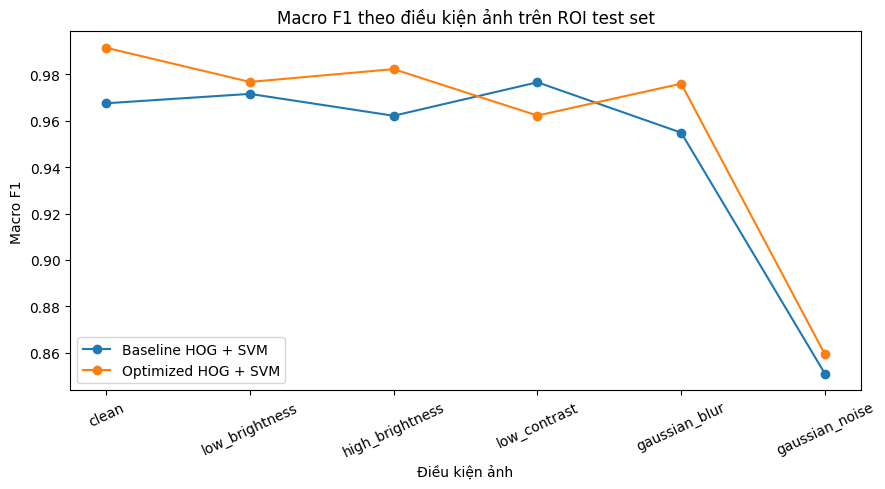

Model tốt nhất trên test sạch là Optimized HOG + SVM.
Model bền nhất trung bình trên các điều kiện ảnh xấu là Optimized HOG + SVM.
Model tốt nhất trên ảnh sạch cũng là model bền nhất trong robustness benchmark hiện tại.


In [126]:
robustness_summary_rows = []
for model_name, group in robustness_results.groupby("model"):
    clean_macro_f1 = group.loc[group["condition"] == "clean", "macro_f1"].iloc[0]
    non_clean = group[group["condition"] != "clean"]
    avg_robust_macro_f1 = non_clean["macro_f1"].mean()
    worst_case_macro_f1 = non_clean["macro_f1"].min()
    robustness_summary_rows.append({
        "model": model_name,
        "clean_macro_f1": clean_macro_f1,
        "avg_robust_macro_f1": avg_robust_macro_f1,
        "worst_case_macro_f1": worst_case_macro_f1,
        "drop_from_clean": clean_macro_f1 - avg_robust_macro_f1,
    })

robustness_summary = pd.DataFrame(robustness_summary_rows).sort_values("avg_robust_macro_f1", ascending=False)
display(robustness_summary)

fig, ax = plt.subplots(figsize=(9, 5))
for model_name, group in robustness_results.groupby("model"):
    ordered = group.set_index("condition").loc[list(ROBUSTNESS_TRANSFORMS.keys())].reset_index()
    ax.plot(ordered["condition"], ordered["macro_f1"], marker="o", label=model_name)
ax.set_title("Macro F1 theo điều kiện ảnh trên ROI test set")
ax.set_xlabel("Điều kiện ảnh")
ax.set_ylabel("Macro F1")
ax.tick_params(axis="x", rotation=25)
ax.legend()
plt.tight_layout()
plt.show()

best_clean = robustness_summary.sort_values("clean_macro_f1", ascending=False).iloc[0]
best_robust = robustness_summary.sort_values("avg_robust_macro_f1", ascending=False).iloc[0]

print(f"Model tốt nhất trên test sạch là {best_clean['model']}.")
print(f"Model bền nhất trung bình trên các điều kiện ảnh xấu là {best_robust['model']}.")

if best_clean["model"] != best_robust["model"]:
    print("Model tốt nhất trên ảnh sạch không nhất thiết là model bền nhất khi điều kiện ảnh thay đổi.")
else:
    print("Model tốt nhất trên ảnh sạch cũng là model bền nhất trong robustness benchmark hiện tại.")


Ở điều kiện `low_contrast`, Macro F1 của optimized giảm vì HOG phụ thuộc vào độ mạnh gradient. Khi tương phản giảm, các cạnh và ký hiệu trong biển báo trở nên kém rõ, làm histogram hướng gradient thay đổi so với ảnh sạch. Cấu hình optimized dùng ROI lớn hơn và vector HOG dài hơn, nên khai thác nhiều chi tiết nhỏ hơn baseline; khi các chi tiết này bị suy giảm bởi low contrast, biểu diễn HOG có thể bị ảnh hưởng mạnh hơn. Điều này cho thấy optimized cải thiện trên test sạch nhưng vẫn có trade-off về độ nhạy với biến đổi tương phản.

### Failure analysis trên test sạch

Phần này phân tích các lỗi dự đoán của Baseline HOG + SVM và Optimized HOG + SVM trên test set sạch. Mục tiêu là xem cấu hình HOG tối ưu giúp giảm lỗi ở lớp nào, còn nhầm lẫn ở đâu, và có tạo thêm lỗi mới so với baseline hay không.

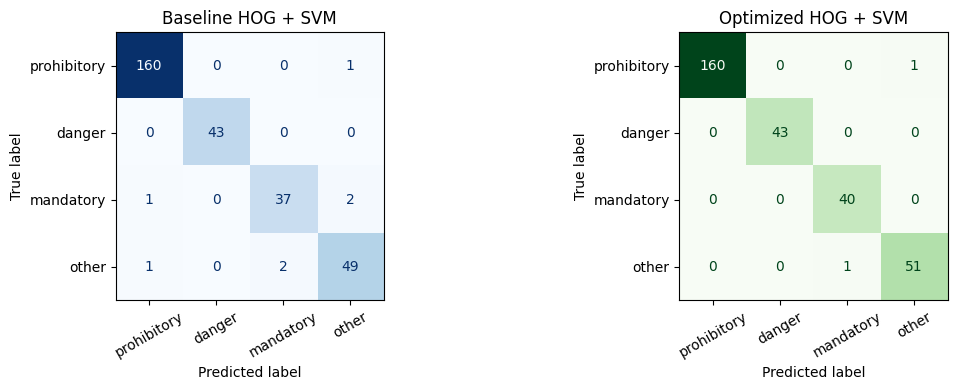

,class,baseline_f1,optimized_f1
0,prohibitory,0.990712,0.996885
1,danger,1.000000,1.000000
2,mandatory,0.936709,0.987654
3,other,0.942308,0.980769


,class,baseline_f1,optimized_f1,delta_f1
0,prohibitory,0.990712,0.996885,0.006173
1,danger,1.000000,1.000000,0.000000
2,mandatory,0.936709,0.987654,0.050945
3,other,0.942308,0.980769,0.038462


In [127]:
baseline_clean_pred = robustness_predictions[("Baseline HOG + SVM", "clean")]
optimized_clean_pred = robustness_predictions[("Optimized HOG + SVM", "clean")]

baseline_cm = confusion_matrix(baseline_clean_pred["y_true"], baseline_clean_pred["y_pred"], labels=GROUP_ORDER)
optimized_cm = confusion_matrix(optimized_clean_pred["y_true"], optimized_clean_pred["y_pred"], labels=GROUP_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay(baseline_cm, display_labels=GROUP_ORDER).plot(ax=axes[0], cmap="Blues", xticks_rotation=30, colorbar=False)
axes[0].set_title("Baseline HOG + SVM")
ConfusionMatrixDisplay(optimized_cm, display_labels=GROUP_ORDER).plot(ax=axes[1], cmap="Greens", xticks_rotation=30, colorbar=False)
axes[1].set_title("Optimized HOG + SVM")
plt.tight_layout()
plt.show()

_, _, baseline_per_class_f1, _ = precision_recall_fscore_support(
    baseline_clean_pred["y_true"],
    baseline_clean_pred["y_pred"],
    labels=GROUP_ORDER,
    average=None,
    zero_division=0,
)
_, _, optimized_per_class_f1, _ = precision_recall_fscore_support(
    optimized_clean_pred["y_true"],
    optimized_clean_pred["y_pred"],
    labels=GROUP_ORDER,
    average=None,
    zero_division=0,
)

per_class_f1 = pd.DataFrame({
    "class": GROUP_ORDER,
    "baseline_f1": baseline_per_class_f1,
    "optimized_f1": optimized_per_class_f1,
})
per_class_delta = per_class_f1.copy()
per_class_delta["delta_f1"] = per_class_delta["optimized_f1"] - per_class_delta["baseline_f1"]

display(per_class_f1)
display(per_class_delta[["class", "baseline_f1", "optimized_f1", "delta_f1"]])


,filename,class_id,y_true,baseline_pred,optimized_pred
6,00025.ppm,40,mandatory,other,mandatory
58,00162.ppm,17,other,mandatory,other
106,00295.ppm,6,other,prohibitory,other
173,00479.ppm,40,mandatory,other,mandatory
210,00641.ppm,17,other,mandatory,other
237,00725.ppm,39,mandatory,prohibitory,mandatory


,filename,class_id,y_true,baseline_pred,optimized_pred
75,00198.ppm,14,other,other,mandatory


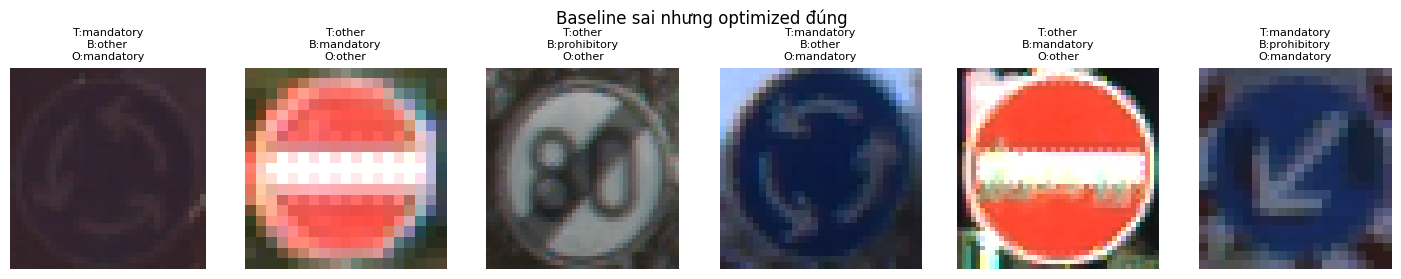

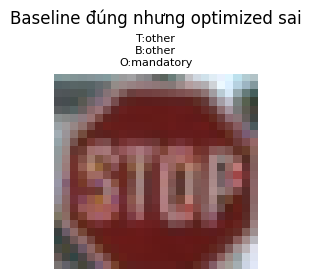

In [128]:
test_df_for_errors = df[df["filename"].isin(test_files)].reset_index(drop=True).copy()
test_df_for_errors["y_true"] = baseline_clean_pred["y_true"]
test_df_for_errors["baseline_pred"] = baseline_clean_pred["y_pred"]
test_df_for_errors["optimized_pred"] = optimized_clean_pred["y_pred"]

baseline_wrong_optimized_correct = test_df_for_errors[
    (test_df_for_errors["baseline_pred"] != test_df_for_errors["y_true"])
    & (test_df_for_errors["optimized_pred"] == test_df_for_errors["y_true"])
]
baseline_correct_optimized_wrong = test_df_for_errors[
    (test_df_for_errors["baseline_pred"] == test_df_for_errors["y_true"])
    & (test_df_for_errors["optimized_pred"] != test_df_for_errors["y_true"])
]

display(baseline_wrong_optimized_correct[["filename", "class_id", "y_true", "baseline_pred", "optimized_pred"]].head(10))
display(baseline_correct_optimized_wrong[["filename", "class_id", "y_true", "baseline_pred", "optimized_pred"]].head(10))


def show_error_examples(example_df, title, max_examples=6):
    if example_df.empty:
        print(f"{title}: không có ví dụ.")
        return
    n = min(max_examples, len(example_df))
    fig, axes = plt.subplots(1, n, figsize=(2.4 * n, 2.8))
    if n == 1:
        axes = [axes]
    for ax, (_, row) in zip(axes, example_df.head(n).iterrows()):
        image = read_image(DATA_ROOT / row["filename"])
        crop = crop_box(image, (row["xmin"], row["ymin"], row["xmax"], row["ymax"]))
        ax.imshow(crop)
        ax.set_title(f"T:{row['y_true']}\nB:{row['baseline_pred']}\nO:{row['optimized_pred']}", fontsize=8)
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


show_error_examples(baseline_wrong_optimized_correct, "Baseline sai nhưng optimized đúng")
show_error_examples(baseline_correct_optimized_wrong, "Baseline đúng nhưng optimized sai")


Qua phần phân tích lỗi sai trên test set sạch, Optimized HOG + SVM sửa được 6 trường hợp mà baseline dự đoán sai, nhưng cũng có 1 trường hợp baseline đúng còn optimized sai. Điều này cho thấy cấu hình optimized cải thiện hiệu quả phân loại tổng thể, tuy nhiên không đảm bảo đúng hơn baseline trên mọi ROI.

## 10. Nhận xét kết quả và hạn chế

Trên test set sạch của split hiện tại, Optimized HOG + SVM đạt Macro F1 khoảng `0.9913`, cao hơn Baseline HOG + SVM khoảng `0.9674`, tương ứng mức tăng khoảng `+0.0239`. Kết quả này cho thấy trong split hiện tại, việc điều chỉnh cấu hình HOG có thể cải thiện hiệu năng phân loại nhóm biển báo trên ROI crop.

Tuy nhiên, kết quả robustness cho thấy hiệu năng của mô hình vẫn giảm khi ROI bị biến đổi ảnh như brightness, contrast, blur hoặc noise. Điều này tương ứng với bản chất của HOG: vector đặc trưng phụ thuộc trực tiếp vào gradient, nên các biến đổi làm yếu, mờ hoặc nhiễu cạnh có thể làm thay đổi biểu diễn HOG và ảnh hưởng đến dự đoán của SVM.

Optimized HOG + SVM tốt hơn trên test sạch, nhưng không có nghĩa là tốt hơn tuyệt đối trên mọi mẫu hoặc mọi điều kiện ảnh. Một số trường hợp baseline đúng nhưng optimized sai vẫn có thể xuất hiện, đặc biệt ở các ROI mờ, tương phản thấp, hoặc có chi tiết cạnh gây nhầm lẫn.

Hạn chế của bài là bài toán hiện tại chỉ đánh giá classification trên ROI crop từ ground-truth bounding box, chưa phát hiện biển báo tự động trên ảnh toàn cảnh. Nhóm dùng một hold-out split cố định để khảo sát, nên kết quả có thể dao động nếu thay đổi random seed hoặc cách chia dữ liệu. Dù split được thực hiện theo filename để tránh ROI từ cùng một ảnh xuất hiện ở cả train và test, việc chọn cấu hình HOG dựa trên test score vẫn làm giảm tính độc lập của đánh giá cuối. Hiệu năng cũng có thể giảm khi ảnh nhiễu mạnh hoặc điều kiện môi trường xấu.

Hướng cải thiện là thêm validation split riêng để chọn cấu hình HOG, sau đó chỉ dùng test set đúng một lần cho đánh giá cuối. Một hướng chắc chắn hơn là grouped cross-validation theo filename và báo cáo trung bình cùng độ lệch chuẩn Macro F1. Ngoài ra, có thể thêm module detection để tạo pipeline end-to-end và bổ sung data augmentation như thay đổi sáng, blur, noise, xoay nhẹ.

# PHỤ LỤC A — KIỂM CHỨNG MỞ RỘNG HOG

## A.1. Vì sao có phụ lục?

Ở phần chính, nhóm đã khảo sát nhiều tham số HOG và chọn được cấu hình phù hợp cho bài toán phân loại nhóm biển báo. Phụ lục này không thay đổi pipeline chính mà chỉ kiểm tra thêm một số điểm.

Thứ nhất, nhóm đánh giá lại Baseline HOG + SVM và Optimized HOG + SVM trên split train/validation/test theo filename. Thứ hai, nhóm thử giảm chiều vector HOG bằng PCA để xem đặc trưng có thể gọn hơn bao nhiêu. Cuối cùng, nhóm kiểm chứng một phiên bản Learnable HOG đơn giản, trong đó các tham số rời rạc được giữ cố định và chỉ một số tham số liên tục được học bằng backpropagation.

Phần chính vẫn là HOG + SVM và Optimized HOG + SVM vẫn là pipeline chính. Các nội dung dưới đây chỉ là kiểm chứng bổ sung, không thay đổi kết luận ở Mục 10.

In [129]:
# A.1-A.2 - Thiết lập riêng, cấu hình tham chiếu và hàm chia dữ liệu
import copy
import math
import random
from sklearn.decomposition import PCA
try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import Dataset, DataLoader
except ImportError as learnable_hog_import_error:
    raise ImportError('Phụ lục Learnable HOG cần PyTorch. Hãy cài PyTorch trước khi chạy phụ lục.') from learnable_hog_import_error
appendix_random_state = int(RANDOM_STATE)
random.seed(appendix_random_state)
np.random.seed(appendix_random_state)
torch.manual_seed(appendix_random_state)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(appendix_random_state)
appendix_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
appendix_optimized_config = copy.deepcopy(optimized_config)
for appendix_tuple_key in ('image_size', 'pixels_per_cell', 'cells_per_block'):
    appendix_optimized_config[appendix_tuple_key] = tuple(appendix_optimized_config[appendix_tuple_key])
appendix_expected_config = {'image_size': (96, 96), 'orientations': 9, 'pixels_per_cell': (8, 8), 'cells_per_block': (2, 2), 'block_norm': 'L2-Hys', 'preprocessing': 'gray_clahe'}
for appendix_config_key, appendix_expected_value in appendix_expected_config.items():
    assert appendix_optimized_config[appendix_config_key] == appendix_expected_value
appendix_label_to_index = {appendix_label: appendix_index for appendix_index, appendix_label in enumerate(GROUP_ORDER)}
appendix_epsilon = 1e-6


def appendix_metric_summary(appendix_targets, appendix_predictions):
    appendix_precision, appendix_recall, appendix_f1, appendix_support = precision_recall_fscore_support(appendix_targets, appendix_predictions, average='macro', zero_division=0)
    return {'accuracy': float(accuracy_score(appendix_targets, appendix_predictions)), 'macro_precision': float(appendix_precision), 'macro_recall': float(appendix_recall), 'macro_f1': float(appendix_f1)}


def appendix_class_counts(appendix_frame, appendix_files):
    return appendix_frame.loc[appendix_frame['filename'].isin(appendix_files), 'label_group'].value_counts().reindex(GROUP_ORDER, fill_value=0)


def appendix_split_score(appendix_frame, appendix_train_value, appendix_val_value, appendix_test_value):
    appendix_total_files = max(1, appendix_frame['filename'].nunique())
    appendix_total_roi = max(1, len(appendix_frame))
    appendix_target = np.asarray([0.80, 0.10, 0.10])
    appendix_values = (appendix_train_value, appendix_val_value, appendix_test_value)
    appendix_file_ratios = np.asarray([len(appendix_value) / appendix_total_files for appendix_value in appendix_values])
    appendix_roi_ratios = np.asarray([appendix_frame['filename'].isin(appendix_value).sum() / appendix_total_roi for appendix_value in appendix_values])
    appendix_full_dist = appendix_frame['label_group'].value_counts(normalize=True).reindex(GROUP_ORDER, fill_value=0.0).to_numpy()
    appendix_dist_penalty = 0.0
    for appendix_value in appendix_values:
        appendix_dist = appendix_frame.loc[appendix_frame['filename'].isin(appendix_value), 'label_group'].value_counts(normalize=True).reindex(GROUP_ORDER, fill_value=0.0).to_numpy()
        appendix_dist_penalty += float(np.abs(appendix_dist - appendix_full_dist).sum())
    return float(np.abs(appendix_file_ratios - appendix_target).sum() + np.abs(appendix_roi_ratios - appendix_target).sum() + 0.25 * appendix_dist_penalty)


def appendix_make_three_way_split(appendix_frame, appendix_seed, appendix_candidates=300):
    appendix_filenames = appendix_frame[['filename']].drop_duplicates()['filename'].to_numpy()
    appendix_file_labels = appendix_frame.groupby('filename')['label_group'].agg(lambda appendix_series: appendix_series.value_counts().idxmax()).reindex(appendix_filenames).to_numpy()
    appendix_required_labels = set(GROUP_ORDER)
    appendix_best_score = np.inf
    appendix_best_split = None
    for appendix_offset in range(int(appendix_candidates)):
        appendix_step_seed = int(appendix_seed) + appendix_offset
        appendix_outer = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=appendix_step_seed)
        appendix_train_indices, appendix_temp_indices = next(appendix_outer.split(appendix_filenames, appendix_file_labels, groups=appendix_filenames))
        appendix_train_value = set(appendix_filenames[appendix_train_indices])
        appendix_temp_filenames = appendix_filenames[appendix_temp_indices]
        appendix_temp_labels = appendix_file_labels[appendix_temp_indices]
        appendix_inner = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=appendix_step_seed + 10007)
        appendix_val_indices, appendix_test_indices = next(appendix_inner.split(appendix_temp_filenames, appendix_temp_labels, groups=appendix_temp_filenames))
        appendix_val_value = set(appendix_temp_filenames[appendix_val_indices])
        appendix_test_value = set(appendix_temp_filenames[appendix_test_indices])
        appendix_label_sets = [set(appendix_class_counts(appendix_frame, appendix_value).loc[lambda appendix_counts: appendix_counts > 0].index) for appendix_value in (appendix_train_value, appendix_val_value, appendix_test_value)]
        if any(appendix_labels != appendix_required_labels for appendix_labels in appendix_label_sets):
            continue
        appendix_candidate_score = appendix_split_score(appendix_frame, appendix_train_value, appendix_val_value, appendix_test_value)
        if appendix_candidate_score < appendix_best_score:
            appendix_best_score = appendix_candidate_score
            appendix_best_split = (appendix_train_value, appendix_val_value, appendix_test_value)
    if appendix_best_split is None:
        raise ValueError('Không tạo được split 80/10/10 theo filename có đủ bốn nhóm lớp.')
    return appendix_best_split


print(f'Thiết bị cho Fixed-config Learnable HOG: {appendix_device}')
print('Cấu hình HOG dùng lại từ phần chính:', appendix_optimized_config)

Thiết bị cho Fixed-config Learnable HOG: cpu
Cấu hình HOG dùng lại từ phần chính: {'image_size': (96, 96), 'orientations': 9, 'pixels_per_cell': (8, 8), 'cells_per_block': (2, 2), 'block_norm': 'L2-Hys', 'preprocessing': 'gray_clahe'}


## A.2. Chia lại train/validation/test theo filename

Ở đây nhóm chia dữ liệu theo filename, không chia từng ROI riêng lẻ. Một ảnh có thể chứa nhiều ROI biển báo; nếu ROI từ cùng một ảnh xuất hiện ở nhiều split khác nhau thì kết quả đánh giá có thể bị lạc quan.

Split hiện có dùng khoảng 80% file cho train, 10% cho validation và 10% cho test. Train dùng để huấn luyện mô hình. Validation dùng để quan sát Baseline/Optimized và chọn số chiều PCA. Test chỉ được dùng ở bước đánh giá cuối. Bảng bên dưới giữ nguyên số lượng file, ROI và phân bố lớp của split đã tạo.

In [130]:
# A.2 - Tạo split train/validation/test theo filename và hiển thị thống kê
appendix_source_df = df.copy(deep=True)
appendix_train_files, appendix_val_files, appendix_test_files = appendix_make_three_way_split(appendix_source_df, appendix_random_state)
assert appendix_train_files.isdisjoint(appendix_val_files)
assert appendix_train_files.isdisjoint(appendix_test_files)
assert appendix_val_files.isdisjoint(appendix_test_files)
appendix_train_df = appendix_source_df[appendix_source_df['filename'].isin(appendix_train_files)].copy().reset_index(drop=True)
appendix_val_df = appendix_source_df[appendix_source_df['filename'].isin(appendix_val_files)].copy().reset_index(drop=True)
appendix_test_df = appendix_source_df[appendix_source_df['filename'].isin(appendix_test_files)].copy().reset_index(drop=True)
appendix_split_rows = []
for appendix_split_name, appendix_split_df in (('train', appendix_train_df), ('validation', appendix_val_df), ('test', appendix_test_df)):
    appendix_present_classes = [appendix_label for appendix_label in GROUP_ORDER if appendix_label in set(appendix_split_df['label_group'])]
    assert set(appendix_present_classes) == set(GROUP_ORDER)
    appendix_split_rows.append({'split': appendix_split_name, 'n_files': int(appendix_split_df['filename'].nunique()), 'n_roi': int(len(appendix_split_df)), 'roi_ratio': float(len(appendix_split_df) / max(1, len(appendix_source_df))), 'classes': ', '.join(appendix_present_classes)})
appendix_split_summary = pd.DataFrame(appendix_split_rows)
appendix_split_class_table = pd.DataFrame({'train': appendix_class_counts(appendix_source_df, appendix_train_files), 'validation': appendix_class_counts(appendix_source_df, appendix_val_files), 'test': appendix_class_counts(appendix_source_df, appendix_test_files)})
print('Split được thực hiện theo filename; ba tập file không giao nhau.')
display(appendix_split_summary)
display(appendix_split_class_table)

Split được thực hiện theo filename; ba tập file không giao nhau.


,split,n_files,n_roi,roi_ratio,classes
0,train,592,973,0.802143,"prohibitory, danger, mandatory, other"
1,validation,74,122,0.100577,"prohibitory, danger, mandatory, other"
2,test,75,118,0.097279,"prohibitory, danger, mandatory, other"


,train,validation,test
label_group,,,
prohibitory,447,57,53
danger,175,23,21
mandatory,130,14,19
other,221,28,25


## A.3. Kiểm tra Baseline và Optimized HOG + SVM trên split mới

Phần này không chọn lại toàn bộ tham số HOG. Nhóm chỉ chạy lại hai cấu hình đã có trên cùng split train/validation/test:

- **Baseline HOG + SVM** dùng cấu hình mặc định ở phần chính.
- **Optimized HOG + SVM** dùng cấu hình đã được chọn sau phần khảo sát tham số.

Mục đích là có một đối chứng rõ ràng hơn trong cùng một cách chia dữ liệu. Baseline cho biết mức kết quả của cấu hình đơn giản ban đầu, còn Optimized cho biết cấu hình đã chọn ở phần chính còn giữ được hiệu năng tốt hay không khi kiểm tra lại bằng validation và test riêng. StandardScaler và LinearSVC chỉ được fit trên train; test không được dùng để chọn tham số.

## A.4. Giảm chiều vector HOG bằng PCA

HOG thường tạo ra vector đặc trưng khá dài. Với cấu hình Optimized, vector có 4356 chiều. Vì vậy, nhóm thử PCA để kiểm tra xem có thể giảm số chiều mà Macro F1 vẫn giữ gần với đặc trưng gốc hay không.

Validation được dùng để chọn số chiều PCA. Tiêu chí là ưu tiên số chiều nhỏ nhất có validation Macro F1 giảm không quá 0.01 so với Optimized HOG; nếu không có mức nào đạt thì chọn mức có validation Macro F1 cao nhất. Test chỉ được dùng sau khi số chiều đã được chọn xong. Đây là phần mở rộng theo hướng làm đặc trưng gọn hơn, không nhằm chứng minh PCA luôn cho kết quả tốt hơn.

## A.5. Learnable HOG với cấu hình cố định

Phần này không cố học toàn bộ tham số HOG. Các tham số rời rạc như image size, số orientation bin, cell size, block size, block norm và preprocessing được giữ cố định theo Optimized HOG. Nhóm chỉ cho một số tham số liên tục học bằng backpropagation.

| Giữ cố định theo Optimized HOG | Được học bằng backpropagation |
|---|---|
| image size = 96×96 | gradient kernels |
| orientations = 9 | orientation bin centers |
| pixels per cell = 8×8 | concentration |
| cells per block = 2×2 | gates |
| block norm = L2-Hys | L2-Hys clip |
| preprocessing = gray_clahe | linear classifier |

Mô hình được train cố định 25 epoch; trong 5 epoch đầu, kernel Sobel được giữ cố định. Validation chỉ dùng để theo dõi đường học, không dùng để chọn checkpoint. Test chỉ đánh giá trạng thái cuối. Mục tiêu của phần này là kiểm tra các tham số liên tục có thể nhận gradient và thay đổi hay không, chứ không dùng Learnable HOG để thay thế pipeline chính.

### Một số đạo hàm cục bộ trong quá trình backpropagation

Các công thức dưới đây được suy ra bằng chain rule trên đúng các phép toán dùng trong mô hình. Đây là đạo hàm cục bộ của một vài bước chính, không phải toàn bộ đạo hàm từ loss qua mọi bước của HOG.

#### Gate của orientation bin

Giả sử vote mềm của bin $k$ là:

$$
V_k = m\,a_k\,g_k
$$

Trong đó $m$ là gradient magnitude, $a_k$ là mức gán mềm vào bin và $g_k$ là gate. Khi xem $m$ và $a_k$ là đầu vào của bước này:

$$
\frac{\partial L}{\partial g_k}
=
\frac{\partial L}{\partial V_k}\,m\,a_k
$$

Trong code, optimizer cập nhật `gate_logit` $q_k$ chứ không cập nhật trực tiếp $g_k$. Do:

$$
g_k = \sigma(q_k)
$$

nên gradient theo tham số thật còn đi qua sigmoid:

$$
\frac{\partial L}{\partial q_k}
=
\frac{\partial L}{\partial g_k}\,g_k(1-g_k)
$$

Nếu bin đóng góp theo hướng làm giảm loss thì gate có thể tăng; nếu bin gây nhiễu thì gate có thể giảm. Các thành phần regularization của gate cũng đóng góp thêm vào gradient tổng.

#### Tâm bin hướng

Biểu diễn góc kép tại một pixel và vector tâm bin chuẩn hóa là:

$$
\mathbf{d}(\theta)
=
[\cos(2\theta),\sin(2\theta)]
$$

$$
\hat{\mathbf{u}}_k
=
[\cos(2\mu_k),\sin(2\mu_k)]
$$

Điểm số của bin $k$ có thể viết:

$$
s_k
=
\kappa_k\,\mathbf{d}(\theta)^T\hat{\mathbf{u}}_k
=
\kappa_k\cos(2\theta-2\mu_k)
$$

Softmax được tính trên điểm số của tất cả các bin:

$$
a_k
=
\operatorname{softmax}(\mathbf{s})_k
=
\frac{\exp(s_k)}{\sum_j \exp(s_j)}
$$

Nếu biểu diễn tâm bin bằng góc $\mu_k$, đạo hàm cục bộ là:

$$
\frac{\partial s_k}{\partial \mu_k}
=
2\kappa_k\sin(2\theta-2\mu_k)
$$

Code thực tế học vector thô $\mathbf{u}_k$ trong `bin_matrix`, sau đó chuẩn hóa:

$$
\hat{\mathbf{u}}_k
=
\frac{\mathbf{u}_k}{\lVert\mathbf{u}_k\rVert}
$$

Gradient vì vậy còn đi qua phép chuẩn hóa vector và softmax. Công thức theo $\mu_k$ là cách biểu diễn tương đương, dễ đọc hơn khi giải thích sự dịch chuyển của tâm bin.

#### Ngưỡng clip trong L2-Hys

Giả sử sau lần chuẩn hóa block thứ nhất có giá trị $x_i$. Sau clipping:

$$
z_i = \min(x_i,c)
$$

Đạo hàm cục bộ theo $c$ là:

$$
\frac{\partial z_i}{\partial c}
=
\begin{cases}
1, & x_i>c,\\
0, & x_i<c.
\end{cases}
$$

Đây là đạo hàm chính xác khi $x_i\ne c$. Tại $x_i=c$, hàm không khả vi theo nghĩa cổ điển và autograd sử dụng một quy ước subgradient tại điểm biên.

Trong code, ngưỡng clip được tham số hóa bởi `clip_raw` $r$:

$$
c = 0.05 + 0.45\sigma(r)
$$

Vì vậy, gradient theo tham số thật là:

$$
\frac{\partial L}{\partial r}
=
\frac{\partial L}{\partial c}
\,0.45\sigma(r)\bigl(1-\sigma(r)\bigr)
$$

Gradient $\partial L/\partial c$ ở đây đã bao gồm ảnh hưởng của lần chuẩn hóa L2 thứ hai và các bước tính loss phía sau.

#### Kernel Sobel học được

Trong PyTorch, `F.conv2d` thực hiện phép cross-correlation. Với một vị trí $p$, gradient ảnh theo trục $x$ có thể viết:

$$
G_x[p]
=
\sum_u I[p+u]K_x[u]
$$

Áp dụng chain rule cho từng phần tử của kernel:

$$
\frac{\partial L}{\partial K_x[u]}
=
\sum_p
I[p+u]
\frac{\partial L}{\partial G_x[p]}
$$

Đây là phép cộng gradient trên các image patch mà kernel đã đi qua. Kernel được khởi tạo từ Sobel nhưng được khai báo bằng `nn.Parameter`, nên gradient từ loss và các thành phần regularization có thể cập nhật kernel trong quá trình training.

In [131]:
# A.3 - Đánh giá Baseline/Optimized HOG + SVM trên split train/validation/test
appendix_baseline_config = copy.deepcopy(DEFAULT_HOG_CONFIG)
for appendix_baseline_tuple_key in ("image_size", "pixels_per_cell", "cells_per_block"):
    appendix_baseline_config[appendix_baseline_tuple_key] = tuple(
        appendix_baseline_config[appendix_baseline_tuple_key]
    )

appendix_baseline_X_all, appendix_baseline_y_all, appendix_baseline_filenames_all = build_feature_dataset(
    df,
    DATA_ROOT,
    appendix_baseline_config,
)
appendix_X_all, appendix_y_all, appendix_filenames_all = build_feature_dataset(
    df,
    DATA_ROOT,
    appendix_optimized_config,
)

appendix_baseline_train_mask = np.isin(
    appendix_baseline_filenames_all,
    list(appendix_train_files),
)
appendix_baseline_val_mask = np.isin(
    appendix_baseline_filenames_all,
    list(appendix_val_files),
)
appendix_baseline_test_mask = np.isin(
    appendix_baseline_filenames_all,
    list(appendix_test_files),
)
appendix_train_mask = np.isin(appendix_filenames_all, list(appendix_train_files))
appendix_val_mask = np.isin(appendix_filenames_all, list(appendix_val_files))
appendix_test_mask = np.isin(appendix_filenames_all, list(appendix_test_files))

for appendix_split_masks in (
    (appendix_baseline_train_mask, appendix_baseline_val_mask, appendix_baseline_test_mask),
    (appendix_train_mask, appendix_val_mask, appendix_test_mask),
):
    appendix_split_train_mask, appendix_split_val_mask, appendix_split_test_mask = appendix_split_masks
    assert not np.any(appendix_split_train_mask & appendix_split_val_mask)
    assert not np.any(appendix_split_train_mask & appendix_split_test_mask)
    assert not np.any(appendix_split_val_mask & appendix_split_test_mask)

appendix_baseline_X_train = appendix_baseline_X_all[appendix_baseline_train_mask]
appendix_baseline_y_train = appendix_baseline_y_all[appendix_baseline_train_mask]
appendix_baseline_X_val = appendix_baseline_X_all[appendix_baseline_val_mask]
appendix_baseline_y_val = appendix_baseline_y_all[appendix_baseline_val_mask]
appendix_baseline_X_test = appendix_baseline_X_all[appendix_baseline_test_mask]
appendix_baseline_y_test = appendix_baseline_y_all[appendix_baseline_test_mask]

appendix_X_train, appendix_y_train = (
    appendix_X_all[appendix_train_mask],
    appendix_y_all[appendix_train_mask],
)
appendix_X_val, appendix_y_val = (
    appendix_X_all[appendix_val_mask],
    appendix_y_all[appendix_val_mask],
)
appendix_X_test, appendix_y_test = (
    appendix_X_all[appendix_test_mask],
    appendix_y_all[appendix_test_mask],
)

assert np.array_equal(appendix_baseline_y_train, appendix_y_train)
assert np.array_equal(appendix_baseline_y_val, appendix_y_val)
assert np.array_equal(appendix_baseline_y_test, appendix_y_test)

appendix_baseline_feature_dim = int(appendix_baseline_X_train.shape[1])
appendix_original_feature_dim = int(appendix_X_train.shape[1])

appendix_baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", make_linear_svc(C=1.0)),
])
appendix_optimized_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", make_linear_svc(C=1.0)),
])
appendix_baseline_model.fit(appendix_baseline_X_train, appendix_baseline_y_train)
appendix_optimized_model.fit(appendix_X_train, appendix_y_train)

appendix_baseline_val_predictions = appendix_baseline_model.predict(appendix_baseline_X_val)
appendix_optimized_val_predictions = appendix_optimized_model.predict(appendix_X_val)
appendix_baseline_val_metrics = appendix_metric_summary(
    appendix_baseline_y_val,
    appendix_baseline_val_predictions,
)
appendix_optimized_val_metrics = appendix_metric_summary(
    appendix_y_val,
    appendix_optimized_val_predictions,
)

appendix_baseline_config_text = (
    f"image_size={appendix_baseline_config['image_size']}, "
    f"{appendix_baseline_config['orientations']} bins, "
    f"cell={appendix_baseline_config['pixels_per_cell']}, "
    f"block={appendix_baseline_config['cells_per_block']}, "
    f"{appendix_baseline_config['preprocessing']}"
)
appendix_optimized_config_text = (
    f"image_size={tuple(appendix_optimized_config['image_size'])}, "
    f"{appendix_optimized_config['orientations']} bins, "
    f"cell={tuple(appendix_optimized_config['pixels_per_cell'])}, "
    f"block={tuple(appendix_optimized_config['cells_per_block'])}, "
    f"{appendix_optimized_config['preprocessing']}"
)
appendix_hog_validation_table = pd.DataFrame([
    {
        "model": "Baseline HOG + SVM (Appendix split)",
        "config": appendix_baseline_config_text,
        "feature_dim": appendix_baseline_feature_dim,
        "val_accuracy": appendix_baseline_val_metrics["accuracy"],
        "val_macro_f1": appendix_baseline_val_metrics["macro_f1"],
        "val_macro_f1_gain_vs_baseline": 0.0,
    },
    {
        "model": "Optimized HOG + SVM (Appendix split)",
        "config": appendix_optimized_config_text,
        "feature_dim": appendix_original_feature_dim,
        "val_accuracy": appendix_optimized_val_metrics["accuracy"],
        "val_macro_f1": appendix_optimized_val_metrics["macro_f1"],
        "val_macro_f1_gain_vs_baseline": float(
            appendix_optimized_val_metrics["macro_f1"]
            - appendix_baseline_val_metrics["macro_f1"]
        ),
    },
])
display(appendix_hog_validation_table)
print(
    "Bảng trên chỉ dùng validation để đối chiếu Baseline và Optimized; "
    "kết quả Optimized cũng là mốc tham chiếu cho bước chọn số chiều PCA."
)
print("Test chưa được dùng để tính metric ở bước này.")

,model,config,feature_dim,val_accuracy,val_macro_f1,val_macro_f1_gain_vs_baseline
0,Baseline HOG + SVM (Appendix split),"image_size=(64, 64), 9 bins, cell=(8, 8), bloc...",1764,0.983607,0.972149,0.000000
1,Optimized HOG + SVM (Appendix split),"image_size=(96, 96), 9 bins, cell=(8, 8), bloc...",4356,0.983607,0.973214,0.001066


Bảng trên chỉ dùng validation để đối chiếu Baseline và Optimized; kết quả Optimized cũng là mốc tham chiếu cho bước chọn số chiều PCA.
Test chưa được dùng để tính metric ở bước này.


In [132]:
# A.4 - Thử PCA trên HOG optimized và chọn số chiều bằng validation
compact_pca_components = [128, 256, 512, 1024, 2048]
compact_max_components = min(int(appendix_X_train.shape[0]), int(appendix_X_train.shape[1]))
compact_valid_components = [compact_n for compact_n in compact_pca_components if compact_n < compact_max_components]
if not compact_valid_components:
    raise ValueError('Không có số chiều PCA hợp lệ.')
compact_candidate_models = {}
compact_validation_rows = []
for compact_n_components in compact_valid_components:
    compact_candidate_model = Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=compact_n_components, svd_solver='randomized', random_state=appendix_random_state)), ('model', make_linear_svc(C=1.0))])
    compact_candidate_model.fit(appendix_X_train, appendix_y_train)
    compact_val_predictions = compact_candidate_model.predict(appendix_X_val)
    compact_val_metrics = appendix_metric_summary(appendix_y_val, compact_val_predictions)
    compact_candidate_models[compact_n_components] = compact_candidate_model
    compact_validation_rows.append({'n_components': int(compact_n_components), 'compression_ratio': float(1.0 - compact_n_components / appendix_original_feature_dim), 'val_accuracy': compact_val_metrics['accuracy'], 'val_macro_f1': compact_val_metrics['macro_f1'], 'f1_drop_vs_optimized_val': float(appendix_optimized_val_metrics['macro_f1'] - compact_val_metrics['macro_f1'])})
compact_validation_table = pd.DataFrame(compact_validation_rows).sort_values('n_components').reset_index(drop=True)
compact_validation_threshold = max(0.0, appendix_optimized_val_metrics['macro_f1'] - 0.01)
compact_eligible_table = compact_validation_table[compact_validation_table['val_macro_f1'] >= compact_validation_threshold]
if len(compact_eligible_table) > 0:
    compact_selected_row = compact_eligible_table.sort_values(['n_components', 'val_macro_f1'], ascending=[True, False]).iloc[0]
    compact_selection_reason = 'mức nhỏ nhất có validation Macro F1 cách HOG gốc không quá 0.01'
else:
    compact_selected_row = compact_validation_table.sort_values(['val_macro_f1', 'n_components'], ascending=[False, True]).iloc[0]
    compact_selection_reason = 'mức có validation Macro F1 cao nhất'
compact_selected_n_components = int(compact_selected_row['n_components'])
compact_selected_config = {'n_components': compact_selected_n_components, 'selection_reason': compact_selection_reason, 'validation_macro_f1': float(compact_selected_row['val_macro_f1'])}
compact_selected_model = compact_candidate_models[compact_selected_n_components]
display(compact_validation_table)
print('PCA được chọn bằng validation:', compact_selected_config)
print(
    'Nhóm chọn 128D vì đây là số chiều nhỏ nhất có validation Macro F1 '
    'giảm không quá 0.01 so với Optimized HOG. 128D không nhất thiết có '
    'validation Macro F1 cao nhất, nhưng là cấu hình gọn nhất trong ngưỡng chấp nhận.'
)
print('Chưa đánh giá bất kỳ cấu hình PCA nào trên test ở bước này.')

,n_components,compression_ratio,val_accuracy,val_macro_f1,f1_drop_vs_optimized_val
0,128,0.970615,0.983607,0.974209,-0.000995
1,256,0.941230,1.000000,1.000000,-0.026786
2,512,0.882461,0.983607,0.973214,0.000000


PCA được chọn bằng validation: {'n_components': 128, 'selection_reason': 'mức nhỏ nhất có validation Macro F1 cách HOG gốc không quá 0.01', 'validation_macro_f1': 0.9742093528134718}
Nhóm chọn 128D vì đây là số chiều nhỏ nhất có validation Macro F1 giảm không quá 0.01 so với Optimized HOG. 128D không nhất thiết có validation Macro F1 cao nhất, nhưng là cấu hình gọn nhất trong ngưỡng chấp nhận.
Chưa đánh giá bất kỳ cấu hình PCA nào trên test ở bước này.


In [133]:
# A.3-A.4 - Đánh giá test sau khi đã chọn số chiều PCA
appendix_baseline_test_predictions = appendix_baseline_model.predict(
    appendix_baseline_X_test
)
appendix_baseline_test_metrics = appendix_metric_summary(
    appendix_baseline_y_test,
    appendix_baseline_test_predictions,
)
appendix_optimized_test_predictions = appendix_optimized_model.predict(appendix_X_test)
appendix_optimized_test_metrics = appendix_metric_summary(
    appendix_y_test,
    appendix_optimized_test_predictions,
)
compact_test_predictions = compact_selected_model.predict(appendix_X_test)
compact_test_metrics = appendix_metric_summary(appendix_y_test, compact_test_predictions)

appendix_hog_test_table = pd.DataFrame([
    {
        "model": "Baseline HOG + SVM (Appendix split)",
        "feature_dim": appendix_baseline_feature_dim,
        "val_accuracy": appendix_baseline_val_metrics["accuracy"],
        "val_macro_f1": appendix_baseline_val_metrics["macro_f1"],
        "test_accuracy": appendix_baseline_test_metrics["accuracy"],
        "test_macro_f1": appendix_baseline_test_metrics["macro_f1"],
        "val_macro_f1_gain_vs_baseline": 0.0,
        "test_macro_f1_gain_vs_baseline": 0.0,
    },
    {
        "model": "Optimized HOG + SVM (Appendix split)",
        "feature_dim": appendix_original_feature_dim,
        "val_accuracy": appendix_optimized_val_metrics["accuracy"],
        "val_macro_f1": appendix_optimized_val_metrics["macro_f1"],
        "test_accuracy": appendix_optimized_test_metrics["accuracy"],
        "test_macro_f1": appendix_optimized_test_metrics["macro_f1"],
        "val_macro_f1_gain_vs_baseline": float(
            appendix_optimized_val_metrics["macro_f1"]
            - appendix_baseline_val_metrics["macro_f1"]
        ),
        "test_macro_f1_gain_vs_baseline": float(
            appendix_optimized_test_metrics["macro_f1"]
            - appendix_baseline_test_metrics["macro_f1"]
        ),
    },
])
appendix_optimized_summary = appendix_hog_test_table.copy()

compact_test_table = pd.DataFrame([
    {
        "model": "Optimized HOG + SVM (Appendix split)",
        "feature_dim": appendix_original_feature_dim,
        "compression_ratio": 0.0,
        "test_accuracy": appendix_optimized_test_metrics["accuracy"],
        "test_macro_f1": appendix_optimized_test_metrics["macro_f1"],
        "f1_drop_vs_optimized_test": 0.0,
    },
    {
        "model": f"Compact HOG + PCA ({compact_selected_n_components}D) + SVM",
        "feature_dim": compact_selected_n_components,
        "compression_ratio": float(
            1.0 - compact_selected_n_components / appendix_original_feature_dim
        ),
        "test_accuracy": compact_test_metrics["accuracy"],
        "test_macro_f1": compact_test_metrics["macro_f1"],
        "f1_drop_vs_optimized_test": float(
            appendix_optimized_test_metrics["macro_f1"]
            - compact_test_metrics["macro_f1"]
        ),
    },
])
display(appendix_hog_test_table)
print(
    "Trên split phụ lục, Optimized HOG có validation Macro F1 cao hơn Baseline "
    "một chút, nhưng Test Macro F1 của hai cấu hình gần như bằng nhau. Vì vậy, "
    "không nên hiểu rằng Optimized luôn tốt hơn Baseline trong mọi cách chia dữ liệu. "
    "Ý chính là cấu hình Optimized vẫn giữ được hiệu năng tốt trên split mới."
)
display(compact_test_table)
print(
    "PCA giảm vector HOG từ 4356 xuống 128 chiều, tương đương giảm khoảng 97% "
    "số chiều. Test Macro F1 giảm nhẹ so với Optimized HOG gốc. PCA không làm "
    "mô hình tốt hơn, nhưng giúp đặc trưng gọn hơn rất nhiều."
)
print(
    "Baseline, Optimized và Compact HOG chỉ được đánh giá trên test "
    "sau khi số chiều PCA đã được chọn bằng validation."
)

,model,feature_dim,val_accuracy,val_macro_f1,test_accuracy,test_macro_f1,val_macro_f1_gain_vs_baseline,test_macro_f1_gain_vs_baseline
0,Baseline HOG + SVM (Appendix split),1764,0.983607,0.972149,0.991525,0.992717,0.000000,0.0
1,Optimized HOG + SVM (Appendix split),4356,0.983607,0.973214,0.991525,0.992717,0.001066,0.0


Trên split phụ lục, Optimized HOG có validation Macro F1 cao hơn Baseline một chút, nhưng Test Macro F1 của hai cấu hình gần như bằng nhau. Vì vậy, không nên hiểu rằng Optimized luôn tốt hơn Baseline trong mọi cách chia dữ liệu. Ý chính là cấu hình Optimized vẫn giữ được hiệu năng tốt trên split mới.


,model,feature_dim,compression_ratio,test_accuracy,test_macro_f1,f1_drop_vs_optimized_test
0,Optimized HOG + SVM (Appendix split),4356,0.000000,0.991525,0.992717,0.00000
1,Compact HOG + PCA (128D) + SVM,128,0.970615,0.983051,0.985577,0.00714


PCA giảm vector HOG từ 4356 xuống 128 chiều, tương đương giảm khoảng 97% số chiều. Test Macro F1 giảm nhẹ so với Optimized HOG gốc. PCA không làm mô hình tốt hơn, nhưng giúp đặc trưng gọn hơn rất nhiều.
Baseline, Optimized và Compact HOG chỉ được đánh giá trên test sau khi số chiều PCA đã được chọn bằng validation.


In [134]:
# A.5 - Dataset và layer Fixed-config Learnable HOG
class LearnableHOGFixedDataset(Dataset):
    def __init__(self, learnable_hog_frame, learnable_hog_config, learnable_hog_return_filename=False):
        self.learnable_hog_frame = learnable_hog_frame.copy().reset_index(drop=True)
        self.learnable_hog_return_filename = bool(learnable_hog_return_filename)
        self.learnable_hog_tensors = []
        for learnable_hog_row in self.learnable_hog_frame.itertuples(index=False):
            learnable_hog_image = read_image(DATA_ROOT / learnable_hog_row.filename)
            learnable_hog_crop = crop_box(learnable_hog_image, (learnable_hog_row.xmin, learnable_hog_row.ymin, learnable_hog_row.xmax, learnable_hog_row.ymax))
            if learnable_hog_crop.size == 0:
                raise ValueError(f'Crop rỗng: {learnable_hog_row.filename}')
            learnable_hog_processed = preprocess_for_hog(learnable_hog_crop, image_size=tuple(learnable_hog_config['image_size']), preprocessing=learnable_hog_config['preprocessing'])
            self.learnable_hog_tensors.append(torch.as_tensor(learnable_hog_processed, dtype=torch.float32).unsqueeze(0) / 255.0)
    def __len__(self):
        return len(self.learnable_hog_frame)
    def __getitem__(self, learnable_hog_index):
        learnable_hog_row = self.learnable_hog_frame.iloc[int(learnable_hog_index)]
        learnable_hog_tensor = self.learnable_hog_tensors[int(learnable_hog_index)].clone()
        learnable_hog_target = torch.tensor(appendix_label_to_index[learnable_hog_row['label_group']], dtype=torch.long)
        if self.learnable_hog_return_filename:
            return learnable_hog_tensor, learnable_hog_target, learnable_hog_row['filename']
        return learnable_hog_tensor, learnable_hog_target


class FixedConfigLearnableHOGLayer(nn.Module):
    def __init__(self, learnable_hog_config):
        super().__init__()
        self.learnable_hog_orientations = int(learnable_hog_config['orientations'])
        self.learnable_hog_pixels_per_cell = tuple(learnable_hog_config['pixels_per_cell'])
        self.learnable_hog_cells_per_block = tuple(learnable_hog_config['cells_per_block'])
        self.learnable_hog_eps = 1e-6
        assert learnable_hog_config['block_norm'] == 'L2-Hys'
        learnable_hog_sobel = torch.tensor([[[[-1.,0.,1.],[-2.,0.,2.],[-1.,0.,1.]]], [[[-1.,-2.,-1.],[0.,0.,0.],[1.,2.,1.]]]], dtype=torch.float32)
        self.register_buffer('learnable_hog_initial_sobel', learnable_hog_sobel.clone())
        self.learnable_hog_gradient_kernel = nn.Parameter(learnable_hog_sobel.clone())
        learnable_hog_centers = torch.arange(self.learnable_hog_orientations, dtype=torch.float32) * math.pi / self.learnable_hog_orientations
        self.learnable_hog_bin_matrix = nn.Parameter(torch.stack([torch.cos(2 * learnable_hog_centers), torch.sin(2 * learnable_hog_centers)], dim=1))
        self.learnable_hog_concentration_raw = nn.Parameter(torch.full((self.learnable_hog_orientations,), 2.0))
        self.learnable_hog_gate_logit = nn.Parameter(torch.full((self.learnable_hog_orientations,), math.log(9.0)))
        self.learnable_hog_clip_raw = nn.Parameter(torch.tensor(math.log(0.15 / 0.30)))
        learnable_hog_width, learnable_hog_height = tuple(learnable_hog_config['image_size'])
        learnable_hog_cells_y = learnable_hog_height // self.learnable_hog_pixels_per_cell[0]
        learnable_hog_cells_x = learnable_hog_width // self.learnable_hog_pixels_per_cell[1]
        learnable_hog_block_y, learnable_hog_block_x = self.learnable_hog_cells_per_block
        self.learnable_hog_feature_dim = (learnable_hog_cells_y-learnable_hog_block_y+1) * (learnable_hog_cells_x-learnable_hog_block_x+1) * learnable_hog_block_y * learnable_hog_block_x * self.learnable_hog_orientations
    def learnable_hog_normalized_bins(self):
        return F.normalize(self.learnable_hog_bin_matrix, dim=1, eps=self.learnable_hog_eps)
    def learnable_hog_concentration(self):
        return F.softplus(self.learnable_hog_concentration_raw) + self.learnable_hog_eps
    def learnable_hog_gates(self):
        return torch.sigmoid(self.learnable_hog_gate_logit)
    def learnable_hog_clip(self):
        return 0.05 + 0.45 * torch.sigmoid(self.learnable_hog_clip_raw)
    def learnable_hog_bin_degrees(self):
        learnable_hog_bins = self.learnable_hog_normalized_bins()
        return torch.remainder(0.5 * torch.atan2(learnable_hog_bins[:,1], learnable_hog_bins[:,0]) * 180 / math.pi, 180)
    def forward(self, learnable_hog_inputs):
        learnable_hog_gradient = F.conv2d(learnable_hog_inputs, self.learnable_hog_gradient_kernel, padding=1)
        learnable_hog_gx, learnable_hog_gy = learnable_hog_gradient[:,0:1], learnable_hog_gradient[:,1:2]
        learnable_hog_square = learnable_hog_gx.square() + learnable_hog_gy.square()
        learnable_hog_magnitude = torch.sqrt(learnable_hog_square + self.learnable_hog_eps)
        learnable_hog_direction = torch.cat([
            (learnable_hog_gx.square()-learnable_hog_gy.square())/(learnable_hog_square+self.learnable_hog_eps),
            (2*learnable_hog_gx*learnable_hog_gy)/(learnable_hog_square+self.learnable_hog_eps),
        ], dim=1).permute(0,2,3,1).reshape(learnable_hog_inputs.shape[0],-1,2)
        learnable_hog_assignment = torch.softmax(torch.matmul(learnable_hog_direction, self.learnable_hog_normalized_bins().t()) * self.learnable_hog_concentration().view(1,1,-1), dim=-1)
        learnable_hog_votes = learnable_hog_magnitude.flatten(2).transpose(1,2) * learnable_hog_assignment * self.learnable_hog_gates().view(1,1,-1)
        learnable_hog_vote_map = learnable_hog_votes.permute(0,2,1).reshape(learnable_hog_inputs.shape[0], self.learnable_hog_orientations, learnable_hog_inputs.shape[2], learnable_hog_inputs.shape[3])
        learnable_hog_cells = F.avg_pool2d(learnable_hog_vote_map, self.learnable_hog_pixels_per_cell, self.learnable_hog_pixels_per_cell) * float(np.prod(self.learnable_hog_pixels_per_cell))
        learnable_hog_blocks = F.unfold(learnable_hog_cells, kernel_size=self.learnable_hog_cells_per_block, stride=1).transpose(1,2)
        learnable_hog_blocks = F.normalize(learnable_hog_blocks, dim=-1, eps=self.learnable_hog_eps)
        learnable_hog_blocks = torch.clamp(learnable_hog_blocks, max=self.learnable_hog_clip())
        learnable_hog_blocks = F.normalize(learnable_hog_blocks, dim=-1, eps=self.learnable_hog_eps)
        return learnable_hog_blocks.reshape(learnable_hog_inputs.shape[0], -1)


class FixedConfigLearnableHOG(nn.Module):
    def __init__(self, learnable_hog_config, learnable_hog_num_classes):
        super().__init__()
        self.learnable_hog_layer = FixedConfigLearnableHOGLayer(learnable_hog_config)
        self.learnable_hog_classifier = nn.Linear(self.learnable_hog_layer.learnable_hog_feature_dim, int(learnable_hog_num_classes))
    def forward(self, learnable_hog_inputs):
        return self.learnable_hog_classifier(self.learnable_hog_layer(learnable_hog_inputs))


def learnable_hog_regularization(learnable_hog_model, learnable_hog_lambdas):
    learnable_hog_layer = learnable_hog_model.learnable_hog_layer
    learnable_hog_kernel = learnable_hog_layer.learnable_hog_gradient_kernel
    learnable_hog_flat = learnable_hog_kernel.flatten(1)
    learnable_hog_gates = learnable_hog_layer.learnable_hog_gates()
    learnable_hog_bins = learnable_hog_layer.learnable_hog_normalized_bins()
    learnable_hog_similarity = torch.matmul(learnable_hog_bins, learnable_hog_bins.t())
    learnable_hog_mask = torch.triu(torch.ones_like(learnable_hog_similarity, dtype=torch.bool), diagonal=1)
    learnable_hog_parts = {
        'sobel': (learnable_hog_kernel-learnable_hog_layer.learnable_hog_initial_sobel).square().mean(),
        'zero_sum': learnable_hog_flat.sum(1).square().mean(),
        'orthogonality': F.cosine_similarity(learnable_hog_flat[0:1],learnable_hog_flat[1:2]).square().mean(),
        'gate_sparsity': learnable_hog_gates.mean(),
        'gate_binary': (learnable_hog_gates*(1-learnable_hog_gates)).mean(),
        'gate_floor': torch.relu(learnable_hog_gates.new_tensor(max(2.0,0.25*learnable_hog_layer.learnable_hog_orientations))-learnable_hog_gates.sum()).square(),
        'bin_collapse': torch.relu(learnable_hog_similarity[learnable_hog_mask]-0.98).square().mean(),
        'clip_center': (learnable_hog_layer.learnable_hog_clip()-0.20).square(),
    }
    learnable_hog_total = sum(learnable_hog_lambdas[learnable_hog_name]*learnable_hog_value for learnable_hog_name,learnable_hog_value in learnable_hog_parts.items())
    return learnable_hog_total, learnable_hog_parts
def learnable_hog_snapshot(learnable_hog_model):
    with torch.no_grad():
        learnable_hog_layer = learnable_hog_model.learnable_hog_layer
        return {
            'gradient_kernel': learnable_hog_layer.learnable_hog_gradient_kernel.detach().cpu().clone(),
            'bin_degrees': learnable_hog_layer.learnable_hog_bin_degrees().detach().cpu().clone(),
            'concentration': learnable_hog_layer.learnable_hog_concentration().detach().cpu().clone(),
            'gates': learnable_hog_layer.learnable_hog_gates().detach().cpu().clone(),
            'clip': learnable_hog_layer.learnable_hog_clip().detach().cpu().clone(),
            'classifier': torch.cat([learnable_hog_parameter.detach().flatten().cpu() for learnable_hog_parameter in learnable_hog_model.learnable_hog_classifier.parameters()]),
        }


def learnable_hog_grad_norm(learnable_hog_parameters):
    learnable_hog_values = [float(learnable_hog_parameter.grad.detach().norm().cpu()) for learnable_hog_parameter in learnable_hog_parameters if learnable_hog_parameter.grad is not None]
    return float(np.mean(learnable_hog_values)) if learnable_hog_values else 0.0


def learnable_hog_collect_gradients(learnable_hog_model):
    learnable_hog_layer = learnable_hog_model.learnable_hog_layer
    return {
        'kernel_grad_norm': learnable_hog_grad_norm([learnable_hog_layer.learnable_hog_gradient_kernel]),
        'bin_grad_norm': learnable_hog_grad_norm([learnable_hog_layer.learnable_hog_bin_matrix]),
        'concentration_grad_norm': learnable_hog_grad_norm([learnable_hog_layer.learnable_hog_concentration_raw]),
        'gate_grad_norm': learnable_hog_grad_norm([learnable_hog_layer.learnable_hog_gate_logit]),
        'clip_grad_norm': learnable_hog_grad_norm([learnable_hog_layer.learnable_hog_clip_raw]),
        'classifier_grad_norm': learnable_hog_grad_norm(list(learnable_hog_model.learnable_hog_classifier.parameters())),
    }


def learnable_hog_evaluate_loader(learnable_hog_model, learnable_hog_loader, learnable_hog_criterion):
    learnable_hog_model.eval(); learnable_hog_losses=[]; learnable_hog_targets=[]; learnable_hog_predictions=[]
    with torch.no_grad():
        for learnable_hog_batch in learnable_hog_loader:
            learnable_hog_inputs = learnable_hog_batch[0].to(appendix_device, dtype=torch.float32)
            learnable_hog_target = learnable_hog_batch[1].to(appendix_device, dtype=torch.long)
            learnable_hog_logits = learnable_hog_model(learnable_hog_inputs)
            learnable_hog_loss = learnable_hog_criterion(learnable_hog_logits, learnable_hog_target)
            learnable_hog_losses.append(float(learnable_hog_loss.detach().cpu()))
            learnable_hog_predictions.extend(learnable_hog_logits.argmax(1).detach().cpu().numpy().tolist())
            learnable_hog_targets.extend(learnable_hog_target.detach().cpu().numpy().tolist())
    learnable_hog_targets_array=np.asarray(learnable_hog_targets,dtype=np.int64)
    learnable_hog_predictions_array=np.asarray(learnable_hog_predictions,dtype=np.int64)
    learnable_hog_metrics=appendix_metric_summary(learnable_hog_targets_array,learnable_hog_predictions_array)
    learnable_hog_metrics.update({'loss':float(np.mean(learnable_hog_losses)),'targets':learnable_hog_targets_array,'predictions':learnable_hog_predictions_array})
    return learnable_hog_metrics

Epoch 01/25 | train_loss=0.8755 | val_loss=0.4769 | val_macro_f1=0.8779
Epoch 02/25 | train_loss=0.3773 | val_loss=0.3177 | val_macro_f1=0.9032
Epoch 03/25 | train_loss=0.2519 | val_loss=0.2377 | val_macro_f1=0.9485
Epoch 04/25 | train_loss=0.1924 | val_loss=0.2026 | val_macro_f1=0.9592
Epoch 05/25 | train_loss=0.1533 | val_loss=0.1703 | val_macro_f1=0.9721
Epoch 06/25 | train_loss=0.1276 | val_loss=0.1541 | val_macro_f1=0.9592
Epoch 07/25 | train_loss=0.1063 | val_loss=0.1331 | val_macro_f1=0.9592
Epoch 08/25 | train_loss=0.0923 | val_loss=0.1316 | val_macro_f1=0.9592
Epoch 09/25 | train_loss=0.0803 | val_loss=0.1156 | val_macro_f1=0.9721
Epoch 10/25 | train_loss=0.0738 | val_loss=0.1008 | val_macro_f1=0.9721
Epoch 11/25 | train_loss=0.0669 | val_loss=0.1082 | val_macro_f1=0.9592
Epoch 12/25 | train_loss=0.0582 | val_loss=0.1170 | val_macro_f1=0.9592
Epoch 13/25 | train_loss=0.0536 | val_loss=0.0947 | val_macro_f1=0.9721
Epoch 14/25 | train_loss=0.0503 | val_loss=0.0870 | val_macro_f1

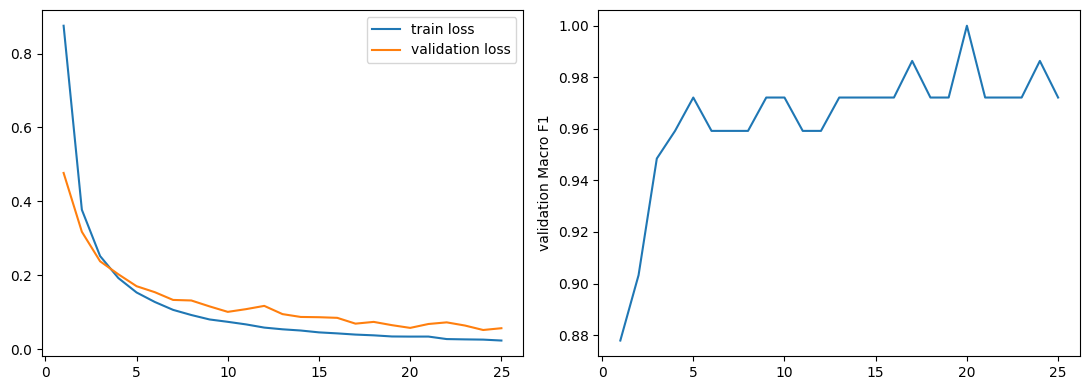

Đã train đủ 25 epoch; validation chỉ dùng để theo dõi, không chọn checkpoint.


In [135]:
# A.5 - Huấn luyện Fixed-config Learnable HOG
learnable_hog_train_dataset=LearnableHOGFixedDataset(appendix_train_df,appendix_optimized_config)
learnable_hog_val_dataset=LearnableHOGFixedDataset(appendix_val_df,appendix_optimized_config)
learnable_hog_batch_size=32
learnable_hog_pin_memory=appendix_device.type=='cuda'
learnable_hog_train_loader=DataLoader(learnable_hog_train_dataset,batch_size=32,shuffle=True,num_workers=0,pin_memory=learnable_hog_pin_memory)
learnable_hog_val_loader=DataLoader(learnable_hog_val_dataset,batch_size=32,shuffle=False,num_workers=0,pin_memory=learnable_hog_pin_memory)
learnable_hog_model=FixedConfigLearnableHOG(appendix_optimized_config,len(GROUP_ORDER)).to(appendix_device)
learnable_hog_train_counts=appendix_train_df['label_group'].value_counts().reindex(GROUP_ORDER,fill_value=0).to_numpy(dtype=np.float32)
learnable_hog_class_weights=torch.as_tensor(learnable_hog_train_counts.sum()/np.maximum(learnable_hog_train_counts,1),dtype=torch.float32,device=appendix_device)
learnable_hog_class_weights/=learnable_hog_class_weights.mean().clamp_min(appendix_epsilon)
learnable_hog_criterion=nn.CrossEntropyLoss(weight=learnable_hog_class_weights)
learnable_hog_lambdas={'sobel':1e-4,'zero_sum':1e-4,'orthogonality':1e-4,'gate_sparsity':1e-5,'gate_binary':1e-4,'gate_floor':1e-3,'bin_collapse':1e-4,'clip_center':1e-5}
learnable_hog_optimizer=torch.optim.AdamW([
 {'params':[learnable_hog_model.learnable_hog_layer.learnable_hog_gradient_kernel],'lr':1e-4},
 {'params':[learnable_hog_model.learnable_hog_layer.learnable_hog_bin_matrix,learnable_hog_model.learnable_hog_layer.learnable_hog_concentration_raw,learnable_hog_model.learnable_hog_layer.learnable_hog_gate_logit,learnable_hog_model.learnable_hog_layer.learnable_hog_clip_raw],'lr':2e-4},
 {'params':list(learnable_hog_model.learnable_hog_classifier.parameters()),'lr':1e-3}],weight_decay=1e-4)
learnable_hog_total_epochs=25
learnable_hog_warmup_epochs=5
learnable_hog_history=[]
learnable_hog_initial_snapshot=learnable_hog_snapshot(learnable_hog_model)
for learnable_hog_epoch in range(1,learnable_hog_total_epochs+1):
    learnable_hog_model.learnable_hog_layer.learnable_hog_gradient_kernel.requires_grad_(learnable_hog_epoch>learnable_hog_warmup_epochs)
    learnable_hog_model.train();learnable_hog_train_losses=[];learnable_hog_epoch_gradients=[]
    for learnable_hog_inputs,learnable_hog_targets in learnable_hog_train_loader:
        learnable_hog_inputs=learnable_hog_inputs.to(appendix_device,dtype=torch.float32);learnable_hog_targets=learnable_hog_targets.to(appendix_device,dtype=torch.long)
        learnable_hog_optimizer.zero_grad(set_to_none=True)
        learnable_hog_logits=learnable_hog_model(learnable_hog_inputs)
        learnable_hog_classification_loss=learnable_hog_criterion(learnable_hog_logits,learnable_hog_targets)
        learnable_hog_regularization_loss,learnable_hog_regularization_parts=learnable_hog_regularization(learnable_hog_model,learnable_hog_lambdas)
        learnable_hog_loss=learnable_hog_classification_loss+learnable_hog_regularization_loss
        learnable_hog_loss.backward();learnable_hog_epoch_gradients.append(learnable_hog_collect_gradients(learnable_hog_model));learnable_hog_optimizer.step();learnable_hog_train_losses.append(float(learnable_hog_loss.detach().cpu()))
    learnable_hog_val_metrics=learnable_hog_evaluate_loader(learnable_hog_model,learnable_hog_val_loader,learnable_hog_criterion)
    learnable_hog_gradient_summary={learnable_hog_name:float(np.mean([learnable_hog_row[learnable_hog_name] for learnable_hog_row in learnable_hog_epoch_gradients])) for learnable_hog_name in ('kernel_grad_norm','bin_grad_norm','concentration_grad_norm','gate_grad_norm','clip_grad_norm','classifier_grad_norm')}
    learnable_hog_history.append({'epoch':learnable_hog_epoch,'train_loss':float(np.mean(learnable_hog_train_losses)),'validation_loss':learnable_hog_val_metrics['loss'],'validation_accuracy':learnable_hog_val_metrics['accuracy'],'validation_macro_f1':learnable_hog_val_metrics['macro_f1'],**learnable_hog_gradient_summary})
    print(f'Epoch {learnable_hog_epoch:02d}/25 | train_loss={learnable_hog_history[-1]["train_loss"]:.4f} | val_loss={learnable_hog_val_metrics["loss"]:.4f} | val_macro_f1={learnable_hog_val_metrics["macro_f1"]:.4f}')
learnable_hog_model.learnable_hog_layer.learnable_hog_gradient_kernel.requires_grad_(True)
learnable_hog_history_df=pd.DataFrame(learnable_hog_history)
learnable_hog_final_snapshot=learnable_hog_snapshot(learnable_hog_model)
learnable_hog_figure,learnable_hog_axes=plt.subplots(1,2,figsize=(11,4))
learnable_hog_axes[0].plot(learnable_hog_history_df['epoch'],learnable_hog_history_df['train_loss'],label='train loss');learnable_hog_axes[0].plot(learnable_hog_history_df['epoch'],learnable_hog_history_df['validation_loss'],label='validation loss');learnable_hog_axes[0].legend()
learnable_hog_axes[1].plot(learnable_hog_history_df['epoch'],learnable_hog_history_df['validation_macro_f1']);learnable_hog_axes[1].set_ylabel('validation Macro F1');plt.tight_layout();plt.show()
print('Đã train đủ 25 epoch; validation chỉ dùng để theo dõi, không chọn checkpoint.')

,model,feature_dim,test_loss,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1
0,Fixed-config Learnable HOG,4356,0.038962,0.983051,0.9775,0.985283,0.981209


,parameter_group,trainable,first_epoch_with_gradient,mean_nonzero_gradient_norm,initial_final_delta,relative_delta,received_gradient,changed_from_initialization,learning_evidence,effect_size_level,interpretation
0,Gradient kernels,True,6,1.398771,0.003575,0.000730,True,True,Có bằng chứng được học,Vừa,Kernel có thể đổi khỏi Sobel nhưng mức đổi nhỏ...
1,Orientation bin centers,True,1,0.022482,0.634710,0.003526,True,True,Có bằng chứng được học,Vừa,Tâm bin có thể dịch nhẹ; điều này chưa tự chứn...
2,Concentration,True,1,0.015459,0.132149,0.020710,True,True,Có bằng chứng được học,Vừa,Concentration điều chỉnh độ sắc của soft assig...
3,Gates,True,1,0.004176,0.005104,0.001890,True,True,Có bằng chứng được học,Vừa,"Gate là trọng số liên tục, không phải số bin đ..."
4,L2-Hys clip,True,1,0.031398,0.008820,0.044100,True,True,Có bằng chứng được học,Vừa,Clip có thể nhận gradient ở phần tử bị cắt ngư...
5,Linear classifier,True,1,0.223135,6.257191,5.412380,True,True,Có bằng chứng được học,Mạnh,Classifier học ranh giới giữa bốn nhóm.


,bin_index,initial_center_deg,final_center_deg,unsigned_shift_deg,initial_gate,final_gate
0,0,0.000000,179.435623,0.564377,0.9,0.901412
1,1,20.000000,20.574726,0.574726,0.9,0.895449
2,2,40.000000,40.535763,0.535763,0.9,0.899566
3,3,60.000000,58.970173,1.029827,0.9,0.900677
4,4,80.000000,81.514633,1.514633,0.9,0.900356
5,5,100.000015,99.187073,0.812943,0.9,0.900241
6,6,120.000008,120.232971,0.232964,0.9,0.898614
7,7,140.000015,139.830475,0.169540,0.9,0.900186
8,8,160.000000,160.277618,0.277618,0.9,0.899254


Fixed-config Learnable HOG có Macro F1 thấp hơn Optimized HOG + SVM. Điều này không làm sai mục tiêu của phần này vì Learnable HOG không được dùng để thay thế mô hình chính.
Có gradient và có cập nhật không đồng nghĩa với việc tham số đó làm kết quả tốt hơn. Phần này chỉ kiểm tra khả năng tham gia backpropagation của một số tham số liên tục.


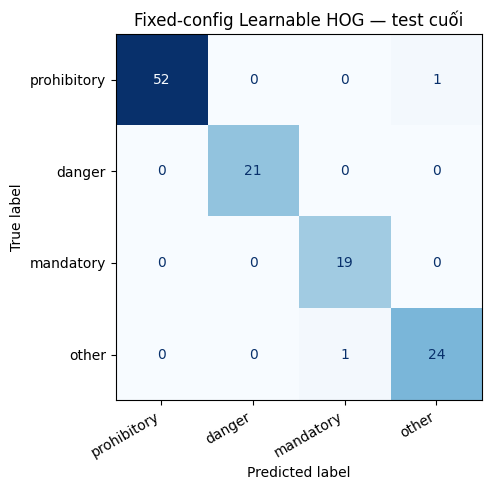

In [136]:
# A.5 - Đánh giá test và kiểm tra bằng chứng tham số được học
learnable_hog_test_dataset=LearnableHOGFixedDataset(appendix_test_df,appendix_optimized_config,True)
learnable_hog_test_loader=DataLoader(learnable_hog_test_dataset,batch_size=32,shuffle=False,num_workers=0,pin_memory=learnable_hog_pin_memory)
learnable_hog_test_metrics=learnable_hog_evaluate_loader(learnable_hog_model,learnable_hog_test_loader,learnable_hog_criterion)
learnable_hog_test_result=pd.DataFrame([{'model':'Fixed-config Learnable HOG','feature_dim':learnable_hog_model.learnable_hog_layer.learnable_hog_feature_dim,'test_loss':learnable_hog_test_metrics['loss'],'test_accuracy':learnable_hog_test_metrics['accuracy'],'test_macro_precision':learnable_hog_test_metrics['macro_precision'],'test_macro_recall':learnable_hog_test_metrics['macro_recall'],'test_macro_f1':learnable_hog_test_metrics['macro_f1']}])


def learnable_hog_unsigned_angle_delta(learnable_hog_initial,learnable_hog_final):
    learnable_hog_delta=np.abs(np.asarray(learnable_hog_final)-np.asarray(learnable_hog_initial))
    return np.minimum(learnable_hog_delta,180-learnable_hog_delta)


def learnable_hog_evidence_label(learnable_hog_received,learnable_hog_changed):
    if learnable_hog_received and learnable_hog_changed:return 'Có bằng chứng được học'
    if learnable_hog_received:return 'Có gradient nhưng gần như không đổi'
    return 'Chưa có bằng chứng nhận gradient'


def learnable_hog_effect_size_label(learnable_hog_delta,learnable_hog_relative):
    if learnable_hog_delta<=1e-8:return 'Gần như không đổi'
    if learnable_hog_relative>=5e-2 or learnable_hog_delta>=1:return 'Mạnh'
    if learnable_hog_relative>=1e-3 or learnable_hog_delta>=1e-3:return 'Vừa'
    return 'Nhỏ'


learnable_hog_initial_angles=learnable_hog_initial_snapshot['bin_degrees'].numpy()
learnable_hog_final_angles=learnable_hog_final_snapshot['bin_degrees'].numpy()
learnable_hog_angle_delta=learnable_hog_unsigned_angle_delta(learnable_hog_initial_angles,learnable_hog_final_angles)
learnable_hog_specs=[
 ('Gradient kernels','kernel_grad_norm',6,float(torch.norm(learnable_hog_final_snapshot['gradient_kernel']-learnable_hog_initial_snapshot['gradient_kernel'])),float(torch.norm(learnable_hog_initial_snapshot['gradient_kernel'])),'Kernel có thể đổi khỏi Sobel nhưng mức đổi nhỏ vẫn có nghĩa là còn gần khởi tạo.'),
 ('Orientation bin centers','bin_grad_norm',1,float(learnable_hog_angle_delta.mean()),180.0,'Tâm bin có thể dịch nhẹ; điều này chưa tự chứng minh F1 được cải thiện.'),
 ('Concentration','concentration_grad_norm',1,float(np.linalg.norm(learnable_hog_final_snapshot['concentration'].numpy()-learnable_hog_initial_snapshot['concentration'].numpy())),float(np.linalg.norm(learnable_hog_initial_snapshot['concentration'].numpy())),'Concentration điều chỉnh độ sắc của soft assignment.'),
 ('Gates','gate_grad_norm',1,float(np.linalg.norm(learnable_hog_final_snapshot['gates'].numpy()-learnable_hog_initial_snapshot['gates'].numpy())),float(np.linalg.norm(learnable_hog_initial_snapshot['gates'].numpy())),'Gate là trọng số liên tục, không phải số bin được học trực tiếp.'),
 ('L2-Hys clip','clip_grad_norm',1,float(torch.abs(learnable_hog_final_snapshot['clip']-learnable_hog_initial_snapshot['clip'])),abs(float(learnable_hog_initial_snapshot['clip'])),'Clip có thể nhận gradient ở phần tử bị cắt ngưỡng.'),
 ('Linear classifier','classifier_grad_norm',1,float(torch.norm(learnable_hog_final_snapshot['classifier']-learnable_hog_initial_snapshot['classifier'])),float(torch.norm(learnable_hog_initial_snapshot['classifier'])),'Classifier học ranh giới giữa bốn nhóm.'),
]
learnable_hog_evidence_rows=[]
for learnable_hog_group,learnable_hog_column,learnable_hog_start,learnable_hog_delta,learnable_hog_scale,learnable_hog_interpretation in learnable_hog_specs:
    learnable_hog_values=learnable_hog_history_df.loc[learnable_hog_history_df['epoch']>=learnable_hog_start,learnable_hog_column].to_numpy()
    learnable_hog_nonzero=learnable_hog_values[learnable_hog_values>1e-10]
    learnable_hog_first_rows=learnable_hog_history_df.loc[(learnable_hog_history_df['epoch']>=learnable_hog_start)&(learnable_hog_history_df[learnable_hog_column]>1e-10),'epoch']
    learnable_hog_first_epoch=None if learnable_hog_first_rows.empty else int(learnable_hog_first_rows.iloc[0])
    learnable_hog_received=learnable_hog_first_epoch is not None
    learnable_hog_changed=learnable_hog_delta>1e-8
    learnable_hog_relative=learnable_hog_delta/(learnable_hog_scale+appendix_epsilon)
    learnable_hog_evidence_rows.append({'parameter_group':learnable_hog_group,'trainable':True,'first_epoch_with_gradient':learnable_hog_first_epoch,'mean_nonzero_gradient_norm':float(learnable_hog_nonzero.mean()) if learnable_hog_nonzero.size else 0.0,'initial_final_delta':learnable_hog_delta,'relative_delta':learnable_hog_relative,'received_gradient':learnable_hog_received,'changed_from_initialization':learnable_hog_changed,'learning_evidence':learnable_hog_evidence_label(learnable_hog_received,learnable_hog_changed),'effect_size_level':learnable_hog_effect_size_label(learnable_hog_delta,learnable_hog_relative),'interpretation':learnable_hog_interpretation})
learnable_hog_parameter_evidence=pd.DataFrame(learnable_hog_evidence_rows)
learnable_hog_bin_table=pd.DataFrame({'bin_index':np.arange(len(learnable_hog_initial_angles)),'initial_center_deg':learnable_hog_initial_angles,'final_center_deg':learnable_hog_final_angles,'unsigned_shift_deg':learnable_hog_angle_delta,'initial_gate':learnable_hog_initial_snapshot['gates'].numpy(),'final_gate':learnable_hog_final_snapshot['gates'].numpy()})
display(learnable_hog_test_result);display(learnable_hog_parameter_evidence);display(learnable_hog_bin_table)
print(
    'Fixed-config Learnable HOG có Macro F1 thấp hơn Optimized HOG + SVM. '
    'Điều này không làm sai mục tiêu của phần này vì Learnable HOG không được '
    'dùng để thay thế mô hình chính.'
)
print(
    'Có gradient và có cập nhật không đồng nghĩa với việc tham số đó làm kết quả '
    'tốt hơn. Phần này chỉ kiểm tra khả năng tham gia backpropagation của một số '
    'tham số liên tục.'
)
learnable_hog_confusion=confusion_matrix(learnable_hog_test_metrics['targets'],learnable_hog_test_metrics['predictions'],labels=list(range(len(GROUP_ORDER))))
learnable_hog_figure,learnable_hog_axis=plt.subplots(figsize=(6,5));ConfusionMatrixDisplay(learnable_hog_confusion,display_labels=list(GROUP_ORDER)).plot(ax=learnable_hog_axis,cmap='Blues',values_format='d',colorbar=False);learnable_hog_axis.set_title('Fixed-config Learnable HOG — test cuối');plt.xticks(rotation=30,ha='right');plt.tight_layout();plt.show()

## A.6. Nhận xét chung

Phụ lục cho thấy khi kiểm tra lại bằng train/validation/test, Baseline và Optimized đều giữ được kết quả tốt. Optimized không vượt rõ Baseline trên split phụ lục, nên không nên kết luận cấu hình này luôn tốt hơn trong mọi cách chia dữ liệu.

PCA là phần mở rộng thực dụng nhất trong phụ lục. Với 128 chiều, vector HOG giảm khoảng 97% số chiều, trong khi Test Macro F1 chỉ giảm nhẹ. Điều này cho thấy HOG có thể được làm gọn nếu cần ưu tiên tốc độ hoặc bộ nhớ, nhưng không có nghĩa PCA luôn tốt hơn đặc trưng gốc.

Fixed-config Learnable HOG chỉ nên xem là kiểm chứng nhỏ về mặt backpropagation. Một số tham số liên tục của HOG có thể nhận gradient và cập nhật, nhưng kết quả này không chứng minh Learnable HOG tốt hơn HOG thủ công.

Nếu phát triển tiếp, nhóm có thể thử nhiều split hơn, cross-validation hoặc các phương pháp feature selection khác ngoài PCA để kiểm tra độ ổn định của kết quả.